# 3 Exploratory Data Analysis

A systematic survey of the cleaned cohort: distributions, missingness, pairwise associations, and target relationships. The empirical evidence this notebook produces is the justification base for every feature-engineering decision made in notebook 4 and every modeling decision made in notebook 6.

**Why EDA gets its own notebook.** Without a documented EDA pass, every downstream decision becomes opaque. Anyone asking "why was `medical_specialty` rolled up to a top-10?" should be able to point to a specific chart here that shows the long-tail distribution that motivated the rollup. Embedding EDA inside feature-engineering code conflates the *finding* with the *response* and makes the pipeline harder to audit.

**The structure of every section that follows.**

1. A brief "what we are analyzing and why" framing tells the reader what question the section answers.
2. A code cell or two produces the chart or summary.
3. A "conclusion" Markdown cell distills the finding into a few bullet points and notes the consequence for downstream work.

Reading the Markdown alone yields a complete narrative of the dataset's structure without needing to step through the code.


## 3.1 Purpose and Scope

**What this notebook covers.** Univariate distributions (§3.5), pairwise associations (§3.6), and multivariate or target-aware relationships (§3.7), followed by the consolidated modeling recommendations in §3.8.

**What this notebook does not cover.** No transformations are applied to the data. Every feature derivation lives in notebook 4. The line is deliberate: EDA must remain reproducible from `data/cleaned.csv` alone, without any in-notebook side effects that would silently change the inputs.

**Methodological note on collinearity tables.** A few of the bivariate sections compute Pearson and Cramér's V on a fixed train-side sample rather than the full cleaned frame. The reason is that any correlation diagnostic computed on the full frame would include validation and test rows, which is a soft form of leakage. Using only the train slice keeps the EDA results consistent with what the modeling stage actually sees.

> **Scope note on the outcome.** The `readmitted` label is all-cause and does not distinguish planned from unplanned returns; §3.6.10 and §3.7.5 interrogate what that means for the model's clinical claim and for equity.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

# Resolve the data directory relative to the project root rather than the
# notebook cwd so the same path works under 'jupyter nbconvert', an Airflow
# task, or an ad-hoc shell: all three set cwd differently.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "pipeline" else Path.cwd()
# Put PROJECT_ROOT on sys.path so `from helpers...` resolves regardless of cwd,
# not just when cwd happens to be the repo root (same guard NB01/04/05/06/07 use).
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"
df = pd.read_csv(DATA_DIR / "cleaned.csv")
print(f"Shape: {df.shape}")
print(f"Columns ({df.shape[1]}): {df.columns.tolist()}")
df.head(3)

Shape: (99340, 56)
Columns (56): ['patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'readmitted', 'weight_recorded', 'race_missing', 'payer_code_missing', 'medical_specialty_missing', 'A1C_measured', 'glu_measured', 'readmitted_canonical', 'age_mid', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'medical_specialty_grouped', 'log_number_outpatient', 'has_any_number_outpatient', 'log_number_emergency', 'has_any_number_emergency', 'log_number_inpatient', 'has_any_number_inpatient', 'metformin_taking', 'glipizide_taking', 'glyburide_taking', 'insulin_taking', 'n

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,glimepiride,...,readmitted,weight_recorded,race_missing,payer_code_missing,medical_specialty_missing,A1C_measured,glu_measured,readmitted_canonical,age_mid,diag_1_cat,diag_2_cat,diag_3_cat,medical_specialty_grouped,log_number_outpatient,has_any_number_outpatient,log_number_emergency,has_any_number_emergency,log_number_inpatient,has_any_number_inpatient,metformin_taking,glipizide_taking,glyburide_taking,insulin_taking,num_medications_log1p,num_procedures_log1p
0,8222157,Caucasian,Female,[0-10),NaN,NaN,1.0,1,Unknown,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,Unknown,Unknown,1,not_measured,not_measured,No,No,No,...,NO,0,0,1,0,0,0,no,5,250,Unknown,Unknown,Other,0.000000,0,0.0,0,0.000000,0,0,0,0,0,0.693147,0.000000
1,55629189,Caucasian,Female,[10-20),1.0,1.0,7.0,3,Unknown,Unknown,59,0,18,0,0,0,276,250.01,255,9,not_measured,not_measured,No,No,No,...,>30,0,0,1,1,0,0,gt30,15,276,250,Other,Unknown,0.000000,0,0.0,0,0.000000,0,0,0,0,1,2.944439,0.000000
2,86047875,AfricanAmerican,Female,[20-30),1.0,1.0,7.0,2,Unknown,Unknown,11,5,13,2,0,1,648,250,V27,6,not_measured,not_measured,No,No,No,...,NO,0,0,1,1,0,0,no,25,Other,250,Unknown,Unknown,1.098612,1,0.0,0,0.693147,1,0,1,0,0,2.639057,1.791759


## 3.2 Setup and Data Load

**What just happened.** The cleaned cohort is loaded into `df`. Every subsequent cell operates on this single in-memory frame, so any modification (which we deliberately avoid) would propagate silently. Cell outputs printed below pin the shape and target distribution at load time for traceability.


## 3.3 Data Overview and Remaining Missingness

**What we are confirming.** That the cleaning pass in notebook 2 left only the deliberately preserved missingness pattern, and that no unexpected NaN values have crept back in through the §2.10 corrections.

**Why an explicit re-audit at the top of EDA matters.** Cleaning was applied. EDA assumes a specific shape. If the two diverge (an upstream column was renamed, a new MNAR indicator was added, a sentinel re-emerged), every downstream chart silently changes. The check below produces a small table that pins the assumptions for the rest of the notebook.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99340 entries, 0 to 99339
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_nbr                99340 non-null  int64  
 1   race                       99340 non-null  object 
 2   gender                     99340 non-null  object 
 3   age                        99340 non-null  object 
 4   admission_type_id          89196 non-null  float64
 5   discharge_disposition_id   94660 non-null  float64
 6   admission_source_id        92486 non-null  float64
 7   time_in_hospital           99340 non-null  int64  
 8   payer_code                 99340 non-null  object 
 9   medical_specialty          99340 non-null  object 
 10  num_lab_procedures         99340 non-null  int64  
 11  num_procedures             99340 non-null  int64  
 12  num_medications            99340 non-null  int64  
 13  number_outpatient          99340 non-null  int

**Reading the schema dump.** The column count and dtype mix above are the contract that notebook 4 inherits. Any unexpected `object` dtype on a numeric column would indicate that a categorical sentinel survived cleaning and needs to be resolved before feature engineering.

**Highest-missingness columns after cleaning.** Only `max_glu_serum` (around 95% missing) and `A1Cresult` (around 83% missing) still carry NaN values. Both are intentional: the lab was not ordered, and §2.10 promoted the testing decision itself into a `*_measured` flag. The columns `payer_code` and `medical_specialty` carry `"Unknown"` from the §2.7.2 fill, so they do not appear in the NaN audit. §3.3.1 below is the full table that confirms this picture.


In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("pct", ascending=False)
print(f"Columns with missing values: {len(missing_df)} of {df.shape[1]}")
missing_df

Columns with missing values: 3 of 56


,count,pct
admission_type_id,10144,10.21
admission_source_id,6854,6.90
discharge_disposition_id,4680,4.71


**Conclusion: remaining missingness.**

| Column          | Missingness | Reason kept                                                                                                           |
|-----------------|-------------|-----------------------------------------------------------------------------------------------------------------------|
| `max_glu_serum` | very heavy  | Lab test was not ordered. The decision to test is itself signal (§2.7.1). Encoded as a binary flag plus result in §4. |
| `A1Cresult`     | heavy       | Same logic as `max_glu_serum`.                                                                                        |

**Interpretation.** The only NaN values remaining in the cohort are the *deliberately preserved* informative missingness in the two lab columns. Every other column was either filled with `"Unknown"` for transparency or had its rows removed at cleaning. This profile is what notebook 4 expects, and the lab columns will be encoded via the `*_measured` MNAR flag pattern derived in §2.10.


## 3.4 Univariate Analysis

**What this section examines.** Each feature in isolation: distribution, outliers, cardinality, modal value. The goal is to identify anomalies that warrant either a feature-engineering response (a log transform on a heavy right tail, a rollup of a long-tail categorical) or a modeling-time response (class weighting for the target imbalance).

**Why univariate first.** Bivariate and multivariate analyses are only meaningful once each variable's univariate behavior is understood. The tail, for instance, dominates a bivariate correlation against a heavily skewed feature. Without knowing that, the analyst would misread the relationship.


### 3.4.1 Target Variable: `readmitted`

**What we are inspecting.** The distribution of the three-class `readmitted` label, and the implied prevalence of the binary `<30` positive class.

**Why this is the single most consequential univariate chart.** Every metric choice downstream is calibrated against the prevalence printed below. Accuracy, AUC-PR baseline, and class-weight magnitude are all functions of the positive rate. Inspecting it explicitly anchors the rest of the analysis.


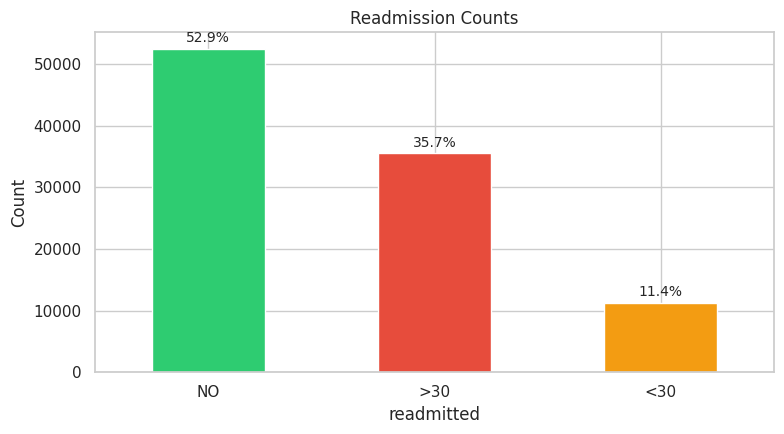

readmitted
NO     52524
>30    35502
<30    11314
Name: count, dtype: int64

Imbalance ratio (NO : <30) = 4.6 : 1


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
target_counts = df["readmitted"].value_counts()
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
target_counts.plot.bar(ax=ax, color=colors, edgecolor="white")
ax.set_title("Readmission Counts")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
_total = target_counts.sum()
for i, (label, cnt) in enumerate(target_counts.items()):
    ax.text(i, cnt + _total * 0.005, f"{cnt / _total * 100:.1f}%",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()
print(target_counts)
print(f"\nImbalance ratio (NO : <30) = {target_counts['NO'] / target_counts['<30']:.1f} : 1")


**Conclusion: target distribution.**

* **`NO`** is the dominant class, followed by **`>30`**, with **`<30`** as the minority positive class at roughly 11% of encounters.
* The binary framing the pipeline uses (`<30` vs everything else) yields a positive rate near 11%. This is the prevalence baseline that AUC-PR and lift are evaluated against.
* The imbalance is severe enough that accuracy is structurally uninformative (a "never readmits" classifier scores roughly 89%). Sections 6 onwards select on F1, AUC-ROC, and AUC-PR rather than accuracy.

**Why this shapes downstream choices.** Class weights (`balanced` for sklearn, `scale_pos_weight` for boosted trees) are applied to compensate for the imbalance in notebook 6. The default threshold of 0.5 is mis-positioned at this prevalence, motivating the threshold sweep in §6.8.


### 3.4.2 Demographics: `race`, `gender`, `age`

**What we are inspecting.** Patient-level demographic attributes. Three things matter here: representation bias (which subgroups dominate the cohort), data quality (any unexpected vocabulary), and shape (numeric distributions for `age`).

**Why representation matters for downstream fairness analysis.** A model trained on a cohort where one race dominates by a wide margin will, by default, fit that race best. The fairness audit gated to §10 (out of scope for this pipeline but referenced in notebook 1) needs to know the per-group sample sizes to set defensible parity bounds.


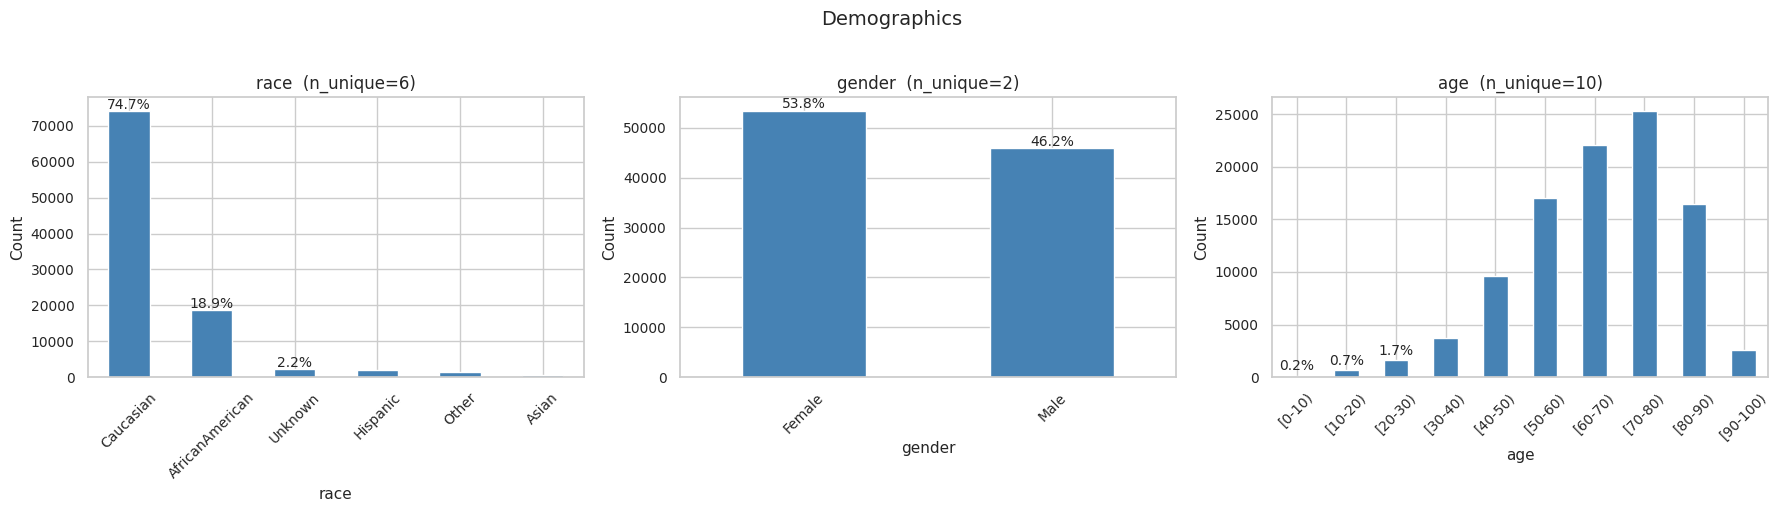

In [5]:
# Age uses a fixed bracket order so the right-skew is visually obvious; race
# and gender stay frequency-sorted because they have no natural ordinal axis.
_AGE_ORDER = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)",
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["race", "gender", "age"]):
    vc = df[col].value_counts()
    if col == "age":
        # Preserve the natural ordinal age ordering instead of frequency order.
        _present = [b for b in _AGE_ORDER if b in vc.index]
        vc = vc.reindex(_present)
    vc.plot.bar(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{col}  (n_unique={df[col].nunique()})", fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    for i, (val, cnt) in enumerate(vc.head(3).items()):
        ax.text(i, cnt + len(df) * 0.005, f"{cnt / len(df) * 100:.1f}%", ha="center", fontsize=10)
plt.suptitle("Demographics", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**Conclusion: demographics.**

* **Race.** Caucasian patients dominate by a wide margin (approximately 75% Caucasian, approximately 19% African American, all other groups at or below 3% each). Models will, by default, fit this subgroup best. Per-group performance reporting is therefore mandatory for any deployment review.
* **Gender.** Roughly balanced after the three invalid rows were removed in §2.5 (about 53% female and 47% male). The 1999-2008 binary gender encoding remains a documented dataset limitation.
* **Age.** Right-skewed towards older brackets, with `[70-80)` carrying the modal share and `[60-70)` second. This is consistent with the diabetic-inpatient population and motivates the age-bracket-to-numeric-midpoint mapping in §4.3.


### 3.4.3 Numeric Features: Hospital Encounter

**What we are inspecting.** The continuous and count features that describe the encounter itself: length of stay, lab procedures, non-lab procedures, medications, and the three prior-utilisation counts.

**Why distributions and outliers both matter.** Linear models and distance-based models are sensitive to scale and outliers. Tree models are not. The shape of these distributions therefore determines which transformations (log, scaling) need to be applied for each model family in notebook 5. The outlier panel doubles as a check that the cleaning pass did not leave any out-of-range sentinel values disguised as legitimate counts.


In [6]:
numeric_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                "num_medications", "number_outpatient", "number_emergency",
                "number_inpatient", "number_diagnoses"]
df[numeric_cols].describe().round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,99340.00,99340.00,99340.00,99340.00,99340.00,99340.00,99340.00,99340.00
mean,4.38,42.91,1.33,15.98,0.37,0.20,0.63,7.40
std,2.97,19.61,1.70,8.09,1.27,0.94,1.26,1.94
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


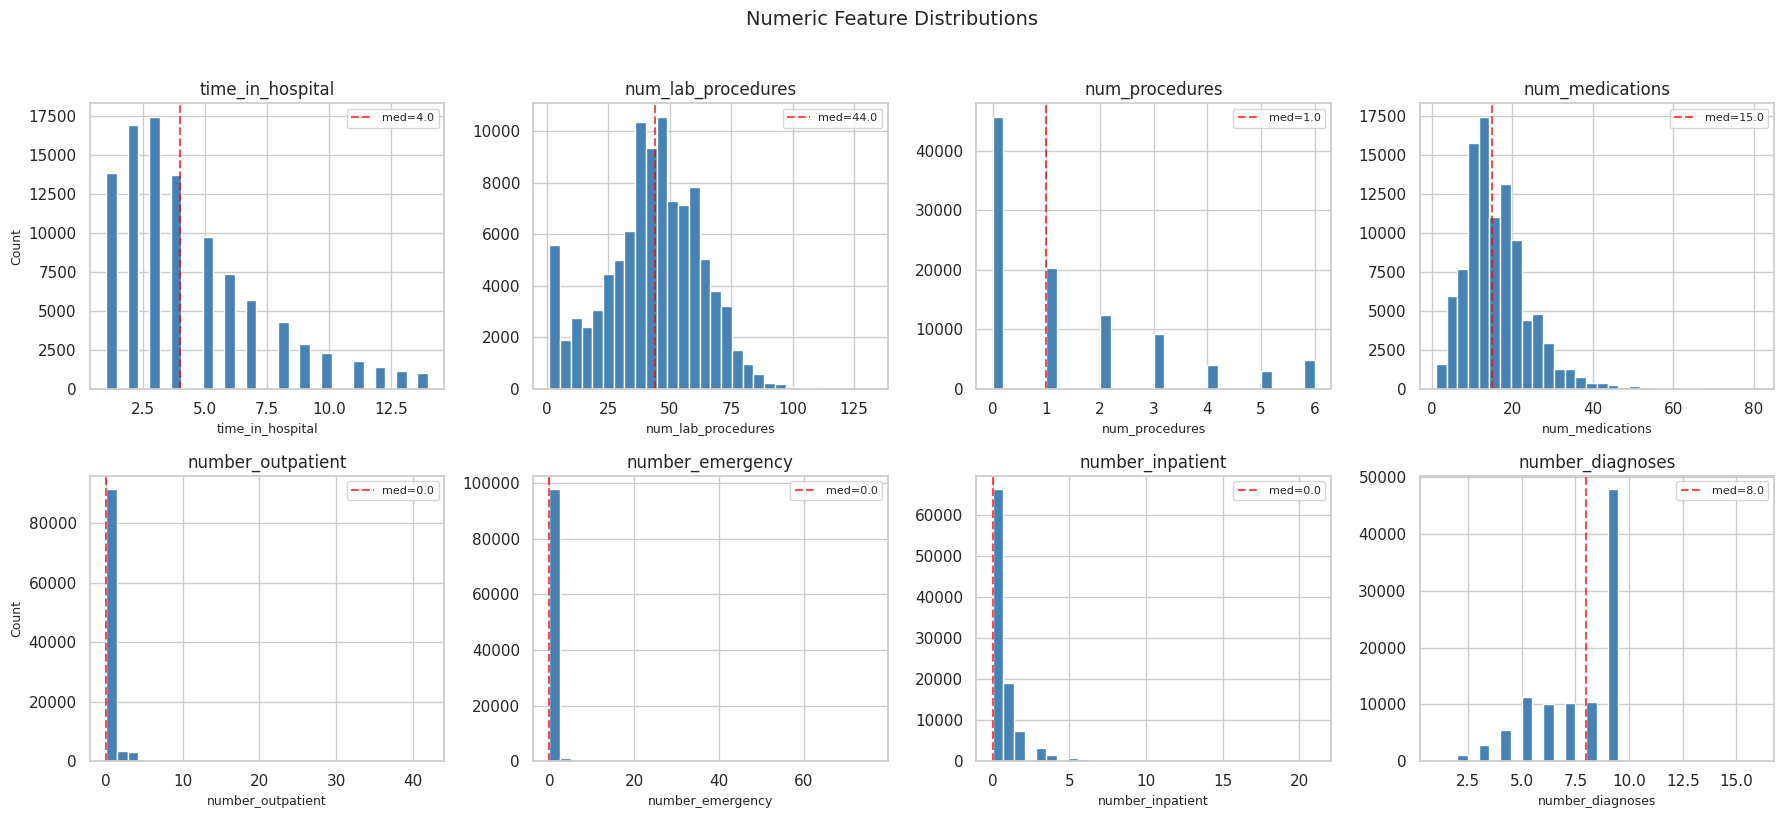

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, (ax, col) in enumerate(zip(axes.flat, numeric_cols)):
    df[col].hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col, fontsize=9)
    if i % 4 == 0:
        ax.set_ylabel("Count", fontsize=9)
    ax.axvline(df[col].median(), color="red", linestyle="--", alpha=0.7, label=f"med={df[col].median():.1f}")
    ax.legend(fontsize=8)
plt.suptitle("Numeric Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

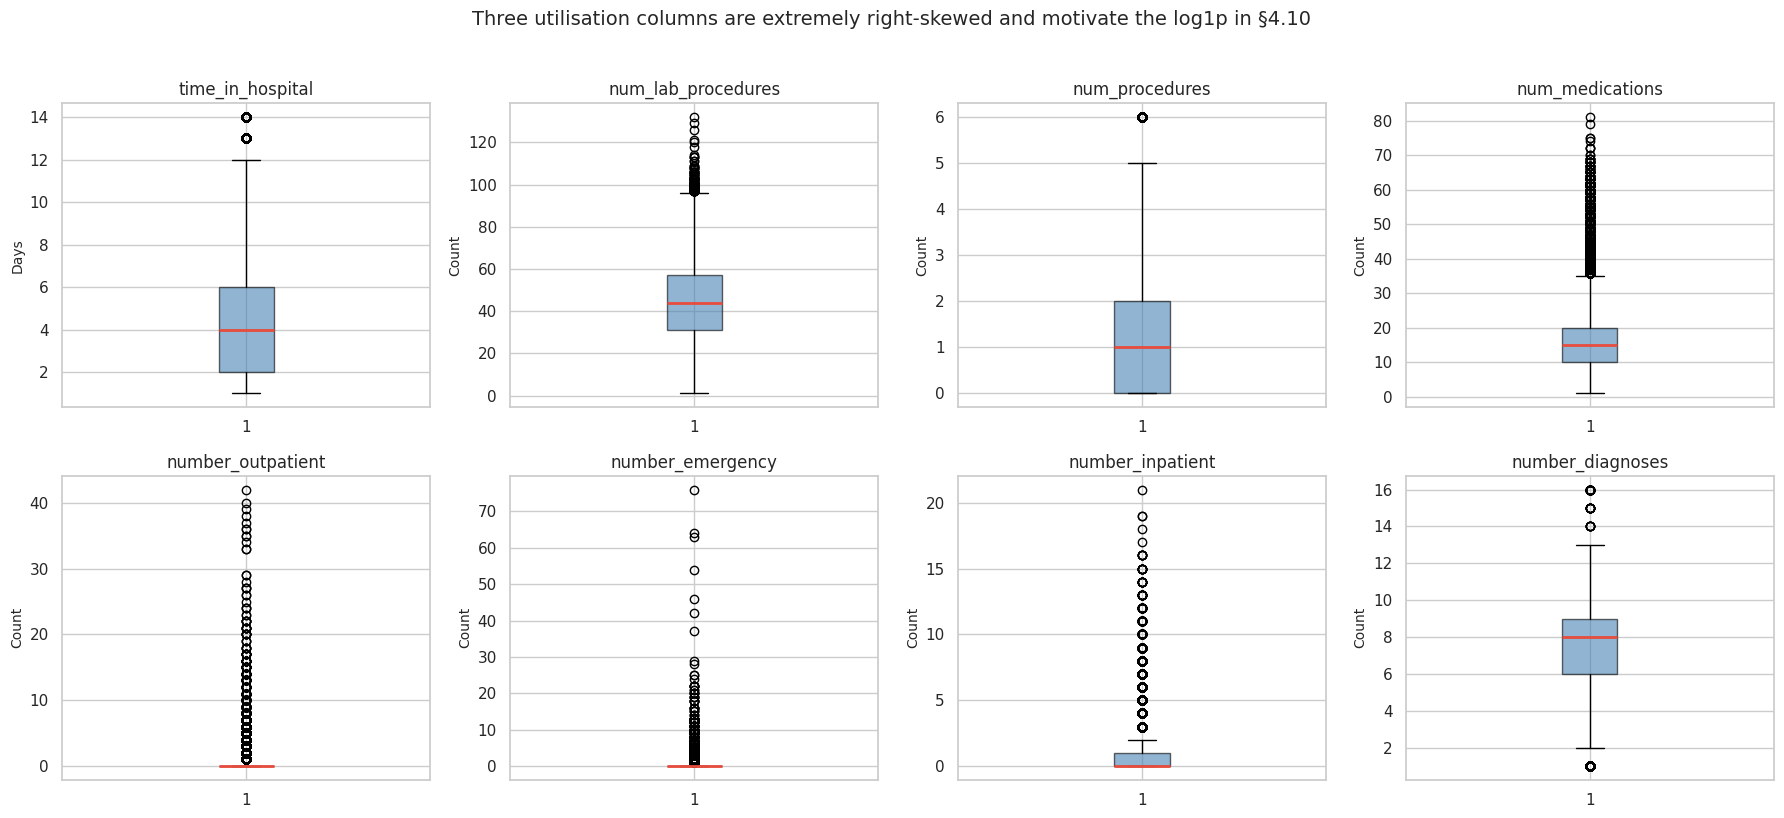

Extreme outliers (beyond 3x IQR):
  num_medications: 418 rows (0.42%)
  number_outpatient: 16,349 rows (16.46%)
  number_emergency: 11,094 rows (11.17%)
  number_inpatient: 1,969 rows (1.98%)


In [8]:
# Outlier detection
_unit_label = {
    "time_in_hospital": "Days",
    "num_lab_procedures": "Count",
    "num_procedures": "Count",
    "num_medications": "Count",
    "number_outpatient": "Count",
    "number_emergency": "Count",
    "number_inpatient": "Count",
    "number_diagnoses": "Count",
}
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numeric_cols):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True)
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][0].set_alpha(0.6)
    bp["medians"][0].set_color("#e74c3c")
    bp["medians"][0].set_linewidth(2)
    ax.set_title(col)
    ax.set_ylabel(_unit_label.get(col, "Count"), fontsize=10)
plt.suptitle("Three utilisation columns are extremely right-skewed and motivate the log1p in §4.10",
             y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# 3*IQR (rather than the 1.5*IQR standard fence) flags only EXTREME outliers. The prior-utilization counts are heavily zero-inflated, and 1.5*IQR would tag a quarter of the rows.
print("Extreme outliers (beyond 3x IQR):")
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_ext = ((df[col] < q1 - 3 * iqr) | (df[col] > q3 + 3 * iqr)).sum()
    if n_ext > 0:
        print(f"  {col}: {n_ext:,} rows ({n_ext / len(df) * 100:.2f}%)")


**Conclusion: numeric features.**

* **`time_in_hospital`** is right-skewed with most stays in the low single digits. A few long stays stretch the tail.
* **`num_lab_procedures`** and **`num_medications`** carry moderate skew. Notebook 4 adds `_log1p` sidecars for the heaviest right tails.
* **`number_inpatient`**, **`number_outpatient`**, and **`number_emergency`** are extremely right-skewed. The vast majority of patients have zero prior visits, with a long tail of high-utilisation patients. These columns are the most aggressively log-transformed in notebook 4.
* **Outliers** in the boxplots are real high-utilisation patients, not data errors. They are the population the model most needs to identify, so they are kept, and the transformations compress the dynamic range rather than clip the values.


### 3.4.4 Diagnosis Codes: `diag_1`, `diag_2`, `diag_3`

**What we are inspecting.** Three ICD-9 diagnosis columns, each with roughly 700 unique values. Tertiary diagnoses are progressively sparser than primary diagnoses.

**Why we group instead of one-hotting raw codes.** Direct one-hot encoding of 700-level categorical variables would produce a 2,000+ column feature matrix dominated by sparsity. The chart below uses the *ICD-9 chapter taxonomy* (about 17 clinical chapters such as Circulatory, Respiratory, Diabetes) for human readability. Production feature engineering in notebook 4 §4.4 takes a different route: it keeps the 15 most-frequent 3-digit ICD-9 prefixes plus `Unknown` plus `Other`, also yielding 17 categories but selected by frequency rather than by chapter. The two views agree on cardinality (17) but encode different groupings.


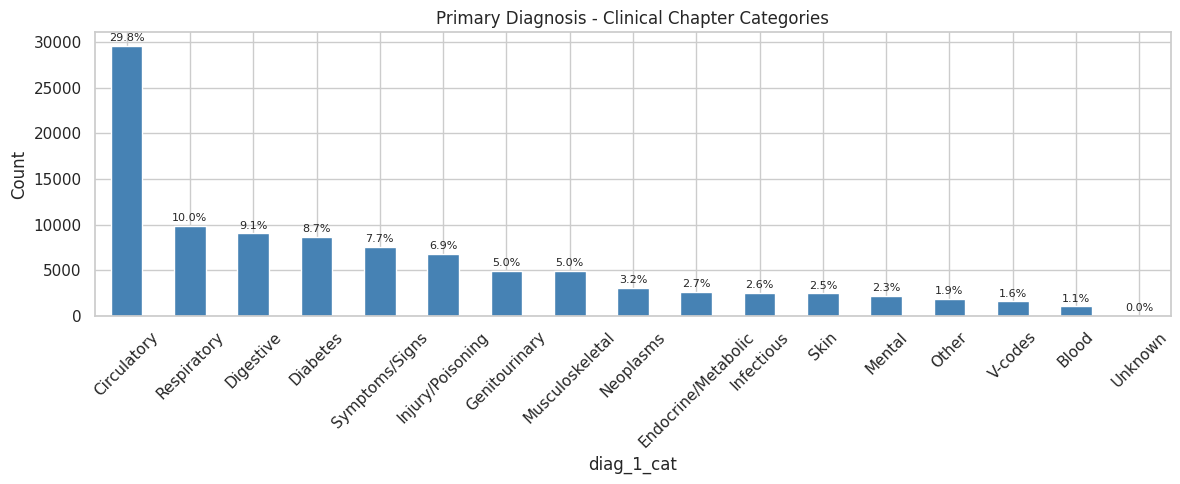

Raw diag_1 codes: 716 -> 17 categories


In [9]:
# ICD-9 codes are mapped to major clinical chapters so that downstream charts
# and narrative speak in human-readable categories ("Circulatory", "Diabetes",
# ...) rather than opaque 3-digit prefixes. Ranges follow the standard ICD-9
# chapter boundaries. 250.x (Diabetes) is broken out from the broader 240-279
# Endocrine/Metabolic block because it is clinically central to this cohort.
# Supplementary V- and E-codes keep their own buckets, and unparseable values
# fall through to "Unknown" / "Other".
def map_icd9(code):
    if pd.isna(code) or str(code).strip() in ("Unknown", ""):
        return "Unknown"
    s = str(code).strip()
    if s[:1].upper() == "V":
        return "V-codes"
    if s[:1].upper() == "E":
        return "E-codes"
    try:
        n = int(float(s))
    except ValueError:
        return "Other"
    # Diabetes is split out from the generic 240-279 endocrine range.
    if n == 250:
        return "Diabetes"
    if 1 <= n <= 139:
        return "Infectious"
    if 140 <= n <= 239:
        return "Neoplasms"
    if 240 <= n <= 279:
        return "Endocrine/Metabolic"
    if 280 <= n <= 289:
        return "Blood"
    if 290 <= n <= 319:
        return "Mental"
    if 320 <= n <= 389:
        return "Nervous/Sensory"
    if 390 <= n <= 459:
        return "Circulatory"
    if 460 <= n <= 519:
        return "Respiratory"
    if 520 <= n <= 579:
        return "Digestive"
    if 580 <= n <= 629:
        return "Genitourinary"
    if 630 <= n <= 679:
        return "Pregnancy"
    if 680 <= n <= 709:
        return "Skin"
    if 710 <= n <= 739:
        return "Musculoskeletal"
    if 740 <= n <= 759:
        return "Congenital"
    if 760 <= n <= 779:
        return "Perinatal"
    if 780 <= n <= 799:
        return "Symptoms/Signs"
    if 800 <= n <= 999:
        return "Injury/Poisoning"
    return "Other"


for col in ["diag_1", "diag_2", "diag_3"]:
    df[f"{col}_cat"] = df[col].apply(map_icd9)

# Keep the top-15 chapters across diag_1/2/3. Fold rare chapters into "Other".
_all_cats = pd.concat([df[c] for c in ["diag_1_cat", "diag_2_cat", "diag_3_cat"]])
top_diag_cats = set(_all_cats.value_counts().head(15).index) | {"Unknown"}
for col in ["diag_1_cat", "diag_2_cat", "diag_3_cat"]:
    df[col] = df[col].where(df[col].isin(top_diag_cats), "Other")

fig, ax = plt.subplots(figsize=(12, 5))
vc = df["diag_1_cat"].value_counts()
vc.plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Primary Diagnosis - Clinical Chapter Categories")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
for i, (cat, cnt) in enumerate(vc.items()):
    ax.text(i, cnt + 500, f"{cnt / len(df) * 100:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()
print(f"Raw diag_1 codes: {df['diag_1'].nunique()} -> {df['diag_1_cat'].nunique()} categories")


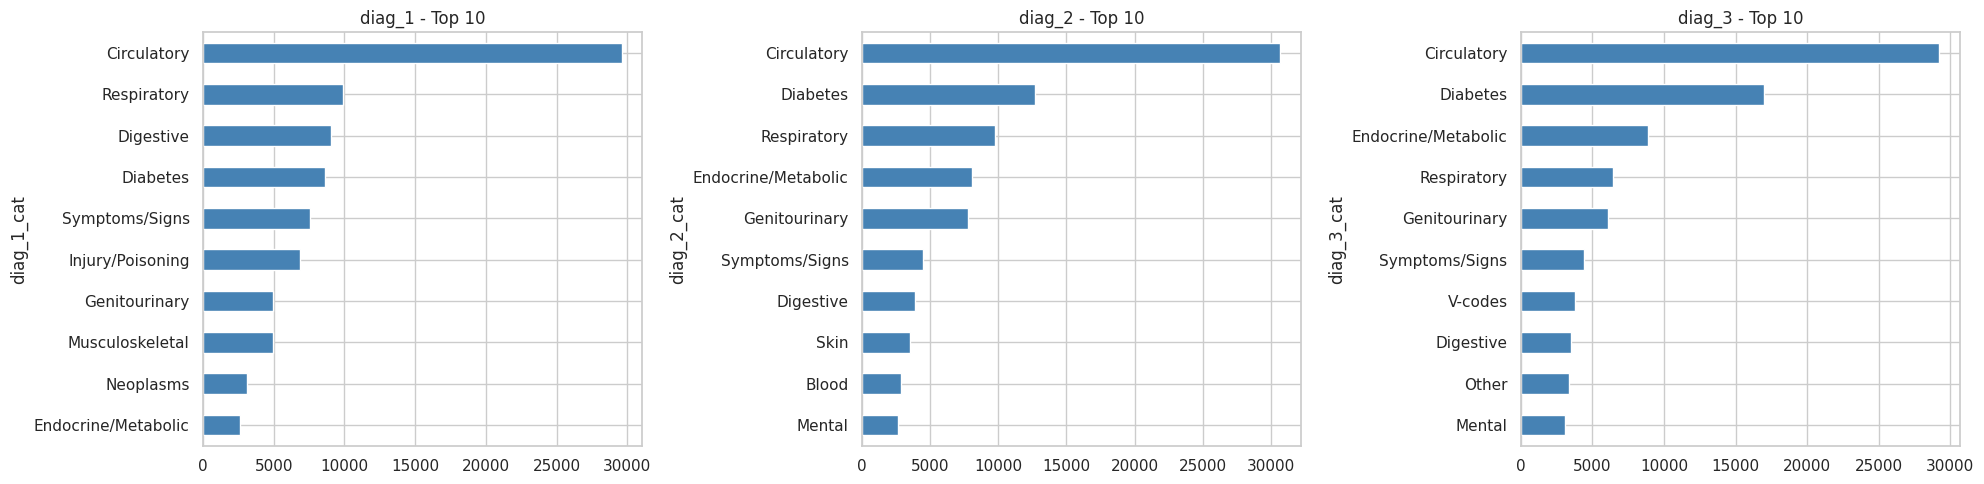

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, col in zip(axes, ["diag_1_cat", "diag_2_cat", "diag_3_cat"]):
    df[col].value_counts().head(10).plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{col.replace('_cat', '')} - Top 10")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Conclusion: diagnosis codes.**

* **Circulatory** is the most common primary diagnosis, followed by Respiratory, Diabetes, and Musculoskeletal. The distribution is consistent with the diabetic-inpatient population (cardiovascular comorbidity is the dominant clinical pattern).
* **Secondary and tertiary diagnoses** show similar shapes but are increasingly distributed across chapters. Higher tertiary `Other` rates indicate that less common conditions appear as supporting rather than primary diagnoses.
* **Why this matters for modelling.** The §4.4 mapper keeps the 15 most-frequent 3-digit ICD-9 prefixes plus an `Unknown` bucket plus an `Other` bucket, yielding 17 categories. The ICD-9 chapter taxonomy (~17 chapters such as Circulatory, Respiratory, Diabetes) shown in the chart above is a different grouping used only in EDA for human readability. The two encodings happen to land on the same cardinality (17) but are selected by different rules: frequency for the production feature, clinical chapter for the EDA view.


### 3.4.5 Lab Results: `max_glu_serum` and `A1Cresult`

**What we are inspecting.** The two direct clinical measurements in the dataset. Both are heavily missing because they are *ordered* tests rather than routine measurements.

**Why their univariate distribution tells two stories simultaneously.** First, what values are reported when the test *is* ordered (the result distribution)? Second, the absence pattern (the testing-rate distribution). The encoding in notebook 4 keeps both signals, which is why the lab columns survive into the feature matrix despite their heavy missingness.


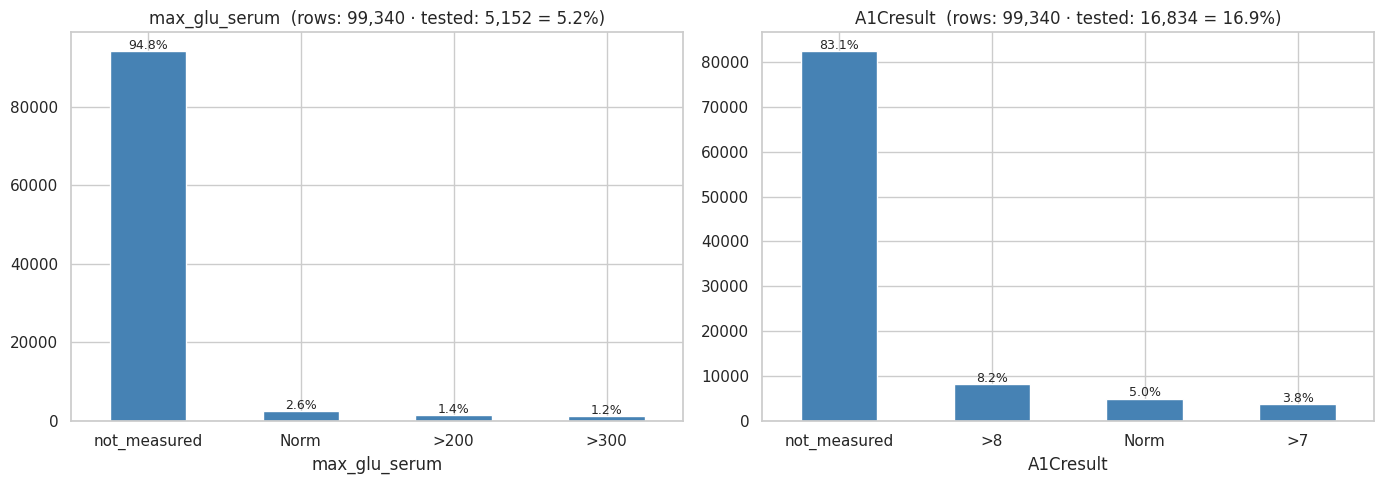

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["max_glu_serum", "A1Cresult"]):
    # The UCI lab columns originally encoded "untested" as the string "None",
    # and the §2.10 cleaning pass refilled NaN with "not_measured". Both
    # sentinels mean the same thing here: the lab was not ordered. Count
    # everything else as a real tested result.
    raw = df[col].astype("object").where(df[col].notna(), "not_measured")
    _UNTESTED = {"None", "not_measured", "Not tested"}
    tested_mask = ~raw.isin(_UNTESTED)
    tested_n = int(tested_mask.sum())
    series = df[col].fillna("Not tested")
    vc = series.value_counts()
    vc.plot.bar(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(
        f"{col}  (rows: {len(df):,} · "
        f"tested: {tested_n:,} = {tested_n / len(df) * 100:.1f}%)"
    )
    ax.tick_params(axis="x", rotation=0)
    for i, (val, cnt) in enumerate(vc.items()):
        ax.text(i, cnt + 500, f"{cnt / len(df) * 100:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


**Conclusion: lab results.**

* **Both `max_glu_serum` and `A1Cresult`** are tested for only a small minority of encounters. The testing decision itself carries a signal (a clinician who suspects poor control orders the test).
* **When tested**, the value distributions are dominated by the "normal" and "moderately elevated" buckets. Extreme values exist but are rare.
* **Encoding strategy.** Notebook 4 encodes each lab as a binary "was tested" flag plus an ordinal result with `"not_measured"` as an explicit level. Imputing a glucose value for an untested patient would fabricate clinical data, so the absence is preserved as its own category.


### 3.4.6 Administrative Codes

**What we are inspecting.** Integer-coded hospital administrative categories: admission type, discharge disposition, admission source. Mapping the integer codes to human-readable labels reveals clinically meaningful distributions that the raw integers obscure.

**Why these are kept as features despite being administrative.** Administrative categories correlate with patient acuity and care pathway. An emergency admission carries a different risk than an elective admission, and a discharge to a skilled-nursing facility carries a different post-discharge risk than a discharge to home. The integers are clinically opaque, but the underlying categories are highly informative.


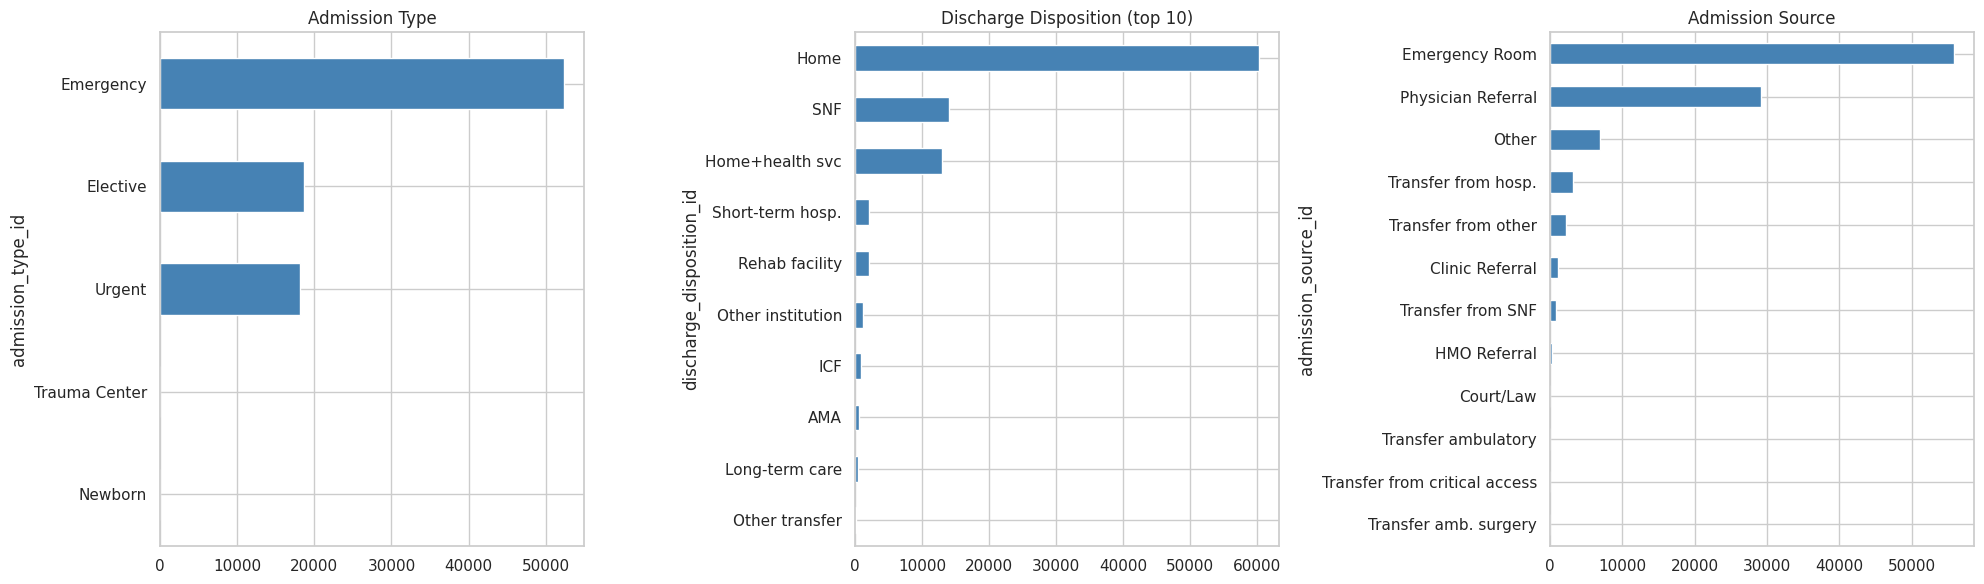

In [12]:
admission_type_map = {
    1: "Emergency", 2: "Urgent", 3: "Elective", 4: "Newborn",
    5: "Not Available", 6: "NULL", 7: "Trauma Center", 8: "Not Mapped"
}
discharge_map = {
    1: "Home", 2: "Short-term hosp.", 3: "SNF", 4: "ICF",
    5: "Other institution", 6: "Home+health svc", 7: "AMA",
    8: "Home IV", 9: "Admitted inpt", 10: "Neonate",
    12: "Still patient", 15: "Swing bed", 16: "Other rehab",
    17: "Unknown", 18: "NULL", 22: "Rehab facility",
    23: "Long-term care", 24: "Medicaid nursing", 25: "Psych hosp.",
    26: "Critical access", 27: "Within institution", 28: "Other transfer",
}
admission_source_map = {
    1: "Physician Referral", 2: "Clinic Referral", 3: "HMO Referral",
    4: "Transfer from hosp.", 5: "Transfer from SNF",
    6: "Transfer from other", 7: "Emergency Room", 8: "Court/Law",
    9: "Not Available", 10: "Transfer from critical access", 17: "NULL",
    20: "Not Mapped", 22: "Transfer ambulatory", 25: "Transfer amb. surgery",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
df["admission_type_id"].map(admission_type_map).value_counts().plot.barh(ax=axes[0], color="steelblue",
                                                                         edgecolor="white")
axes[0].set_title("Admission Type")
axes[0].invert_yaxis()
df["discharge_disposition_id"].map(discharge_map).value_counts().head(10).plot.barh(ax=axes[1], color="steelblue",
                                                                                    edgecolor="white")
axes[1].set_title("Discharge Disposition (top 10)")
axes[1].invert_yaxis()
df["admission_source_id"].map(admission_source_map).fillna("Other").value_counts().plot.barh(ax=axes[2],
                                                                                             color="steelblue",
                                                                                             edgecolor="white")
axes[2].set_title("Admission Source")
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()

**Conclusion: administrative codes.**

* **Admission type.** Emergency dominates the admission-type distribution. Codes 5, 6, and 8 (Not Available, NULL, Not Mapped) were mapped to NaN in §2.4.1 and now form an explicit "missing-administrative" bucket.
* **Discharge disposition.** "Discharged to home" is the most common, followed by various transfer destinations (SNF, ICF, home with health service). The death and hospice codes were removed in §2.4.
* **Admission source.** Heavily concentrated on a few codes (emergency room, physician referral). The long-tail codes are too rare individually to matter as separate features and will be rolled up during feature engineering.


### 3.4.7 Medical Specialty

**What we are inspecting.** The treating physician's specialty. Roughly half the rows carry `"Unknown"` (filled from NaN in §2.7.2), and the remaining values have a long-tail distribution.

**Why a top-K rollup is the right response.** The full vocabulary has dozens of specialties. Many appear in fewer than 100 encounters, which is below the threshold for the model to learn anything from them. Notebook 4's rollup to a top-10 plus `"Other"` is the response to this long tail.


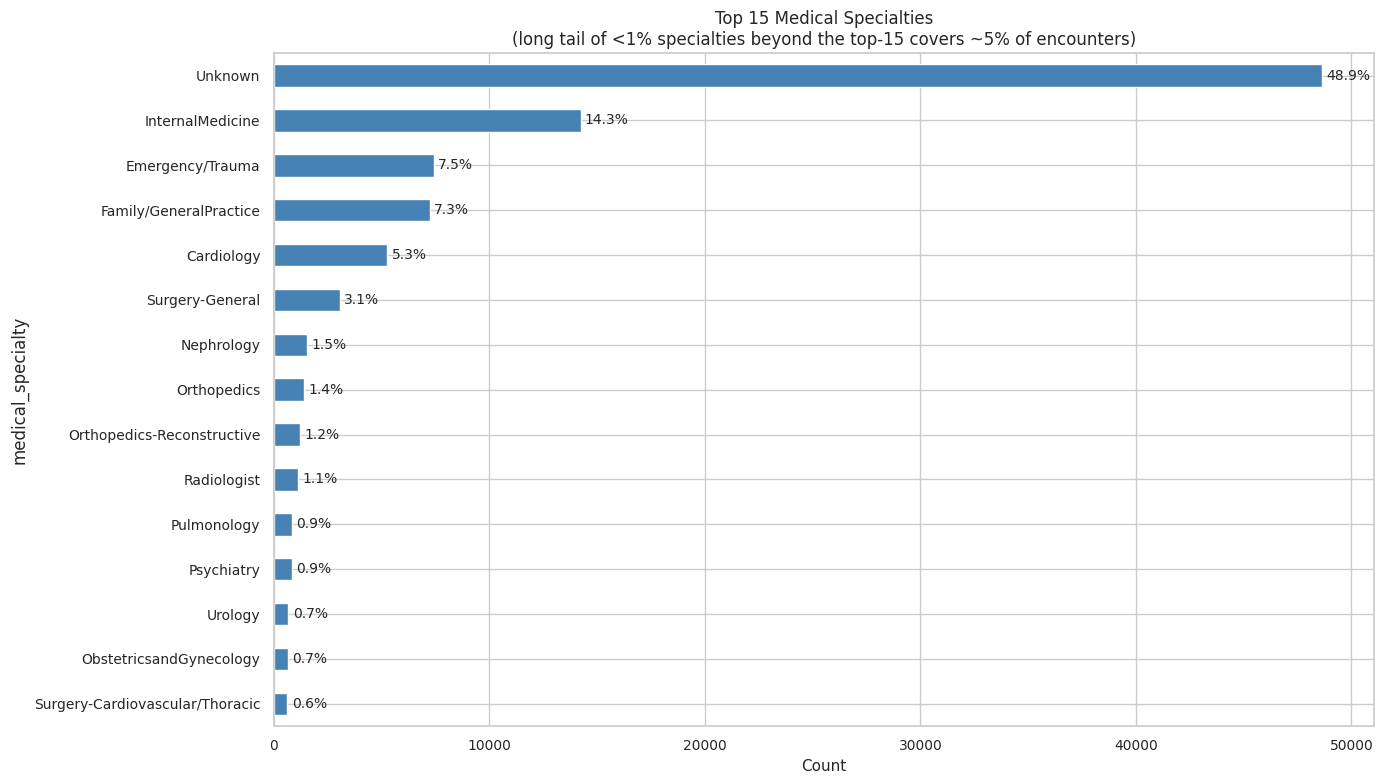

In [13]:
fig, ax = plt.subplots(figsize=(14, 8))
_vc_full = df["medical_specialty"].value_counts()
spec_vc = _vc_full.head(15).copy()
# Fraction of encounters in the long tail beyond the top-15 named specialties.
_long_tail_pct = (1 - spec_vc.sum() / _vc_full.sum()) * 100
_colors = ["#7f8c8d" if name == "Other" else "steelblue" for name in spec_vc.index]
spec_vc.plot.barh(ax=ax, color=_colors, edgecolor="white")
ax.set_title(
    "Top 15 Medical Specialties\n"
    f"(long tail of <1% specialties beyond the top-15 covers ~{_long_tail_pct:.0f}% of encounters)",
    fontsize=12,
)
ax.set_xlabel("Count", fontsize=11)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.invert_yaxis()
for i, (spec, cnt) in enumerate(spec_vc.items()):
    ax.text(cnt + 200, i, f"{cnt / len(df) * 100:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()


**Conclusion: medical specialty.**

* **InternalMedicine** dominates the named-specialty rows, followed by Emergency/Trauma and Family/GeneralPractice. The top three together account for a substantial fraction of the named-specialty population.
* **The `"Unknown"` bucket** is the largest single category overall, reflecting hospital-level recording practices rather than random missingness. Treating it as its own category in feature engineering preserves the systematic-missingness signal.
* **Long tail.** Dozens of specialties appear in fewer than ~1% of encounters each. Notebook 4 §4.6 keeps the top-10 named specialties plus `"Other"` (specialties below the top-10 frequency cut are folded into `"Other"`). The per-group `<30`-day readmission rate across the kept specialties spans a single-digit percentage-point range, which is why specialty enters the model as a categorical encoding rather than as a strong standalone predictor.


### 3.4.8 Payer Code

**What we are inspecting.** Insurance and payer type, a socioeconomic proxy with roughly 40% `"Unknown"` from §2.7.2 fill.

**Why this column is consequential despite the missingness.** Payer correlates with care continuity and post-discharge follow-up access. Medicare, Medicaid, and self-paid patients have different post-discharge support structures, and that structure is one of the strongest non-clinical predictors of readmission risk in the broader literature.


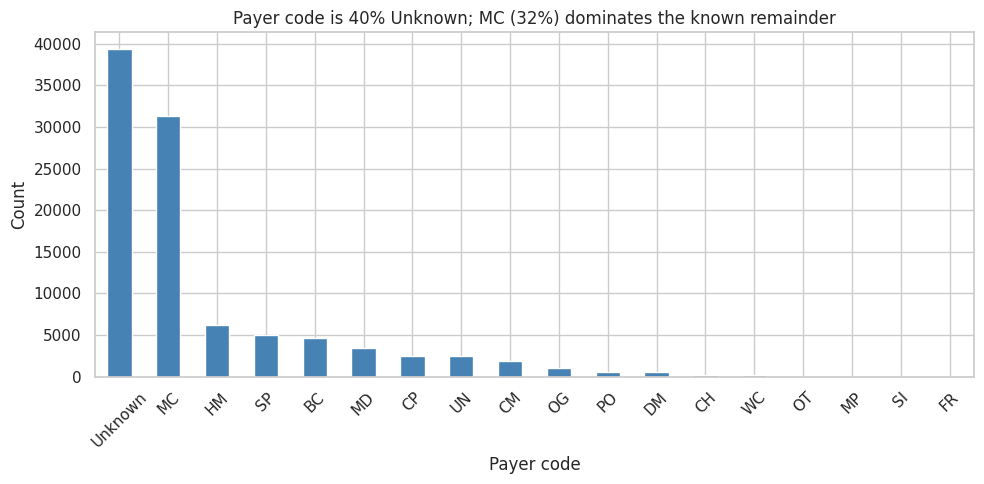

Unique payer codes: 18


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
pc_vc = df["payer_code"].value_counts()
_unknown_pct = pc_vc.get("Unknown", 0) / len(df) * 100
_top_known = pc_vc.drop("Unknown", errors="ignore").idxmax()
_top_known_pct = pc_vc.get(_top_known, 0) / len(df) * 100
pc_vc.plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.set_title(
    f"Payer code is {_unknown_pct:.0f}% Unknown; "
    f"{_top_known} ({_top_known_pct:.0f}%) dominates the known remainder"
)
ax.set_xlabel("Payer code")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print(f"Unique payer codes: {df['payer_code'].nunique()}")


**Conclusion: payer code.**

* **MC (Medicare)** dominates the known-payer distribution, which is expected given the older age skew of the cohort.
* **The 40% `"Unknown"` bucket** is substantial but the feature may still carry signal for the rows that *do* have payer recorded.
* **Notebook 4 rollup.** Keeps the top-5 codes plus `"Unknown"` plus `"Other"`. The long-tail codes are rolled into `"Other"` because they appear too rarely to be useful on their own.


### 3.4.9 Medication Columns

**What we are inspecting.** The diabetes-medication columns that survived the §2.6.3 zero-variance scan. Each records `No`, `Steady`, `Up`, or `Down`.

**Why the prescription-rate distribution matters.** A column where 99% of rows are `"No"` was dropped in §2.6.3. The surviving columns vary in prescription rate from a small minority (the rarer drugs) to a majority prescribed (insulin, metformin). Notebook 4 uses the highest-prevalence four (insulin, metformin, glipizide, glyburide) for binary `*_taking` sidecar flags.


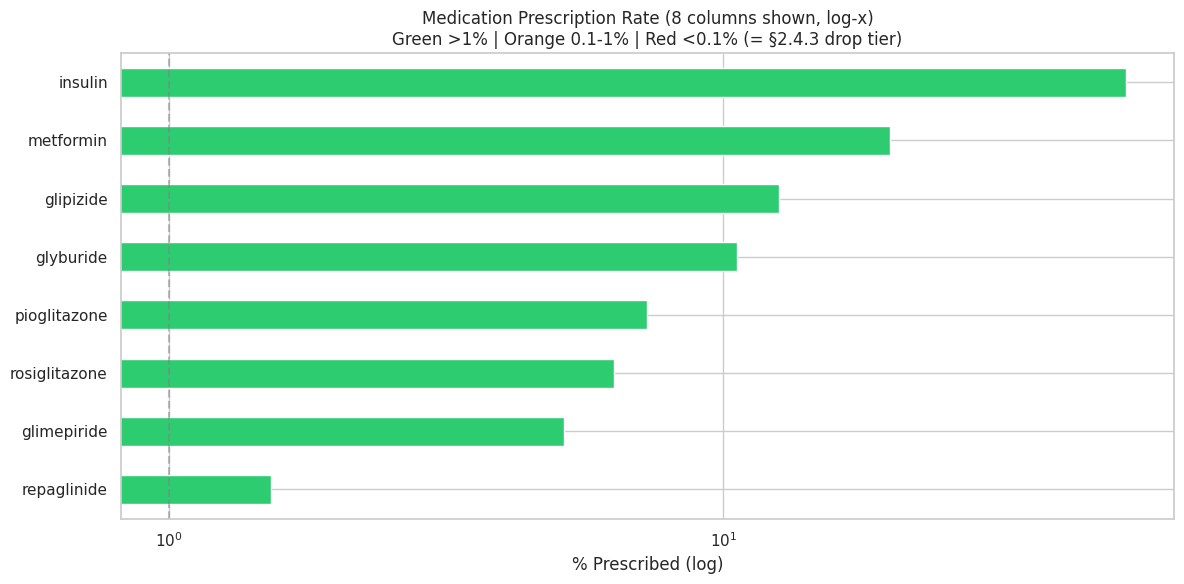

Near-zero variance (<0.5% prescribed):


In [15]:
# Identify medication columns directly from the data: they share the
# characteristic {"No", "Up", "Down", "Steady"} value set.
_drug_vals = {"No", "Up", "Down", "Steady"}
all_med_cols = sorted(
    c for c in df.columns
    if pd.api.types.is_string_dtype(df[c])
    and set(df[c].dropna().unique()) <= _drug_vals
    and "No" in df[c].values
)

med_usage = pd.DataFrame({
    "prescribed_pct": [(df[c] != "No").mean() * 100 for c in all_med_cols],
    "unique_values": [df[c].nunique() for c in all_med_cols],
}, index=all_med_cols).sort_values("prescribed_pct", ascending=False)

# Horizontal log-x so the long-tail of low-prevalence drugs is legible alongside core 4.
# Color-coded by tier, so the reader sees the threshold §2.4.3 applies when dropping near-constant columns.
fig, ax = plt.subplots(figsize=(12, max(6, 0.35 * len(med_usage))))
bar_colors = ["#e74c3c" if p < 0.1 else "#f39c12" if p < 1 else "#2ecc71"
              for p in med_usage["prescribed_pct"]]
med_usage["prescribed_pct"].sort_values().plot.barh(ax=ax, color=list(reversed(bar_colors)), edgecolor="white")
ax.set_xscale("log")
ax.set_title(
    f"Medication Prescription Rate ({len(all_med_cols)} columns shown, log-x)\nGreen >1% | Orange 0.1-1% | Red <0.1% (= §2.4.3 drop tier)")
ax.set_xlabel("% Prescribed (log)")
ax.axvline(x=1, color="gray", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Near-zero variance (<0.5% prescribed):")
for m in med_usage[med_usage["prescribed_pct"] < 0.5].index:
    print(f"  {m}: {med_usage.loc[m, 'prescribed_pct']:.3f}%")


**Conclusion: medications.**

* **Core 4.** Insulin, metformin, glipizide, and glyburide are the most frequently prescribed and carry the strongest variation. Notebook 4 derives `*_taking` binary flags for these four.
* **Mid-prevalence.** Pioglitazone and rosiglitazone are prescribed for a meaningful minority of patients. Kept categorical only. The prevalence is too low for a useful `*_taking` binary flag after the §2.10 stricter threshold.
* **Tail.** The remaining surviving drugs are rare prescriptions but carry enough variation to be useful when combined with other features.


### 3.4.10 Summary Flag: `change`

**What we are inspecting.** Binary medication management summary. `change = Ch` means any medication dosage was changed during the encounter. `change = No` means no medication changes.

**Why the readmission rate by `change` deserves an early look.** This is the simplest possible "did the clinician do something during the encounter" feature. If the readmission rate differs materially between the two groups, the feature is informative on its own and worth keeping even though it duplicates information from the per-drug columns.


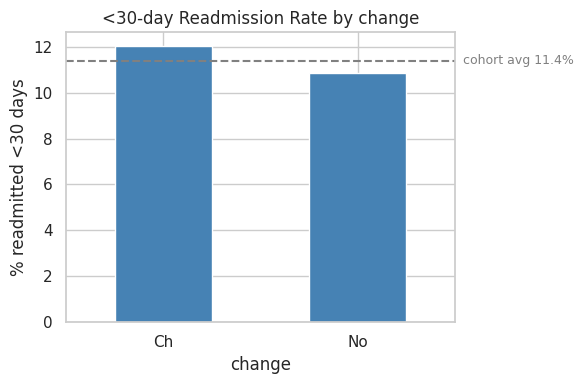

In [16]:
# Plot readmission rate by the 'change' flag
fig, ax = plt.subplots(figsize=(6, 4))
col = "change"
readm_rate = (df["readmitted"] == "<30").astype(int).groupby(df[col]).mean() * 100
cohort_rate = (df["readmitted"] == "<30").astype(int).mean() * 100
readm_rate.plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.axhline(cohort_rate, ls="--", color="gray")
# Annotate the reference line directly so no single-entry legend is needed.
ax.text(
    ax.get_xlim()[1], cohort_rate, f"  cohort avg {cohort_rate:.1f}%",
    color="gray", va="center", ha="left", fontsize=9,
)
ax.set_title(f"<30-day Readmission Rate by {col}")
ax.set_ylabel("% readmitted <30 days")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


**Conclusion: `change` flag.** A large share of encounters had any medication change recorded. The readmission-rate gap between `Ch` and `No` is modest. The feature is kept because it is inexpensive to encode (single binary) and contributes a small amount of signal that the per-drug columns alone do not fully capture.


### 3.4.11 Duplicate Patients

**What we are confirming.** The same fact the §2.6.4 cleaning step quantified, but viewed univariately as the encounters-per-patient distribution. This is the structural fact that forces the patient-grouped split in notebook 5.

**Why it deserves its own EDA section.** The leakage risk is the single most consequential structural property of this dataset. Restating it in EDA terms gives a reader who only reads notebook 3 the same warning that a reader of notebook 2 §2.6.4 gets.


Unique patients:   69,987
Total encounters:  99,340
Ratio:             1.42 encounters/patient

Encounters per patient:
count    69987.00
mean         1.42
std          1.09
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         40.00
Name: count, dtype: float64


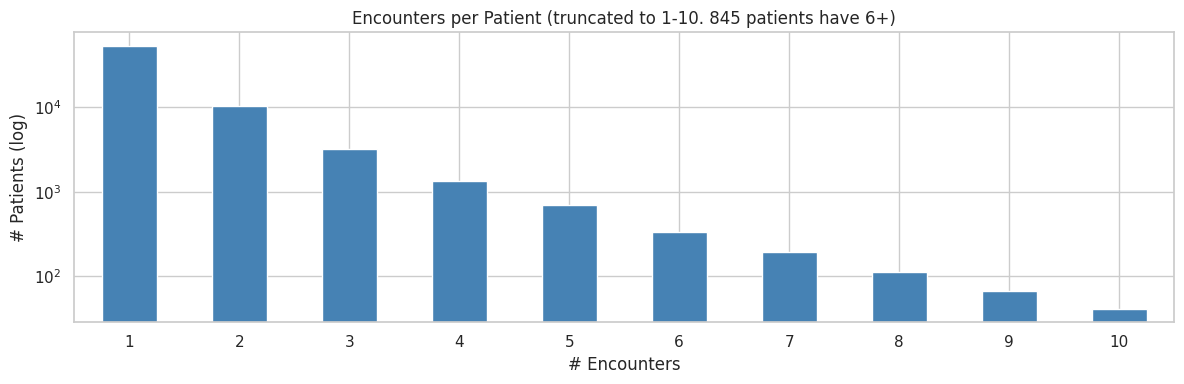


Patients with 5+: 1,536 | 10+: 136


In [17]:
epp = df["patient_nbr"].value_counts()
print(f"Unique patients:   {df['patient_nbr'].nunique():,}")
print(f"Total encounters:  {len(df):,}")
print(f"Ratio:             {len(df) / df['patient_nbr'].nunique():.2f} encounters/patient")
print("\nEncounters per patient:")
print(epp.describe().round(2))

fig, ax = plt.subplots(figsize=(12, 4))
# Truncate the x-axis to 1-10 (where >99% of patients live) and pool 6+ into a single annotated bar
# so the long-tail does not flatten the visible bars.
_epp_counts = epp.value_counts().sort_index()
_top10 = _epp_counts.loc[_epp_counts.index <= 10]
_pooled_6plus = _epp_counts.loc[_epp_counts.index >= 6].sum()
_top10.plot.bar(ax=ax, color=["steelblue"] * len(_top10), edgecolor="white")
ax.tick_params(axis="x", rotation=0)
ax.set_title(f"Encounters per Patient (truncated to 1-10. {_pooled_6plus:,} patients have 6+)")
ax.set_xlabel("# Encounters")
ax.set_ylabel("# Patients (log)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()
print(f"\nPatients with 5+: {(epp >= 5).sum():,} | 10+: {(epp >= 10).sum():,}")

**Conclusion: duplicate patients.** The unique-patient count is materially smaller than the encounter count, so a row-level random split would route the same patient into both train and test. Notebook 5's `StratifiedGroupKFold` on `patient_nbr` is the only correct response. Notebook 4 §4.14.1 further reinforces this by deferring patient-history features until *after* the split, so they can only be computed from the patient's own training encounters.


## 3.5 Bivariate Analysis

**What this section examines.** Pairwise relationships between features, independent of the target variable. The goal is to detect collinearity (which affects linear models) and natural groupings of features that move together.

**Why bivariate before multivariate.** Multivariate analysis assumes you understand which pairs of variables are tightly linked. Without that knowledge, multivariate plots become impossible to read because every visible pattern could be driven by a hidden collinear pair rather than a genuine joint effect.


### 3.5.1 Numeric Feature Scatter Matrix

**What we are plotting.** Pairwise scatter plots for a focused set of four numeric features. The matrix is restricted to four variables (rather than all numeric features) so that each panel is large enough to read.

**Why focused beats exhaustive.** A 10x10 scatter matrix is unreadable. A 4x4 matrix that covers the variables most likely to interact (length of stay, medications, prior visits, lab procedures) shows the same patterns at a human-legible scale.


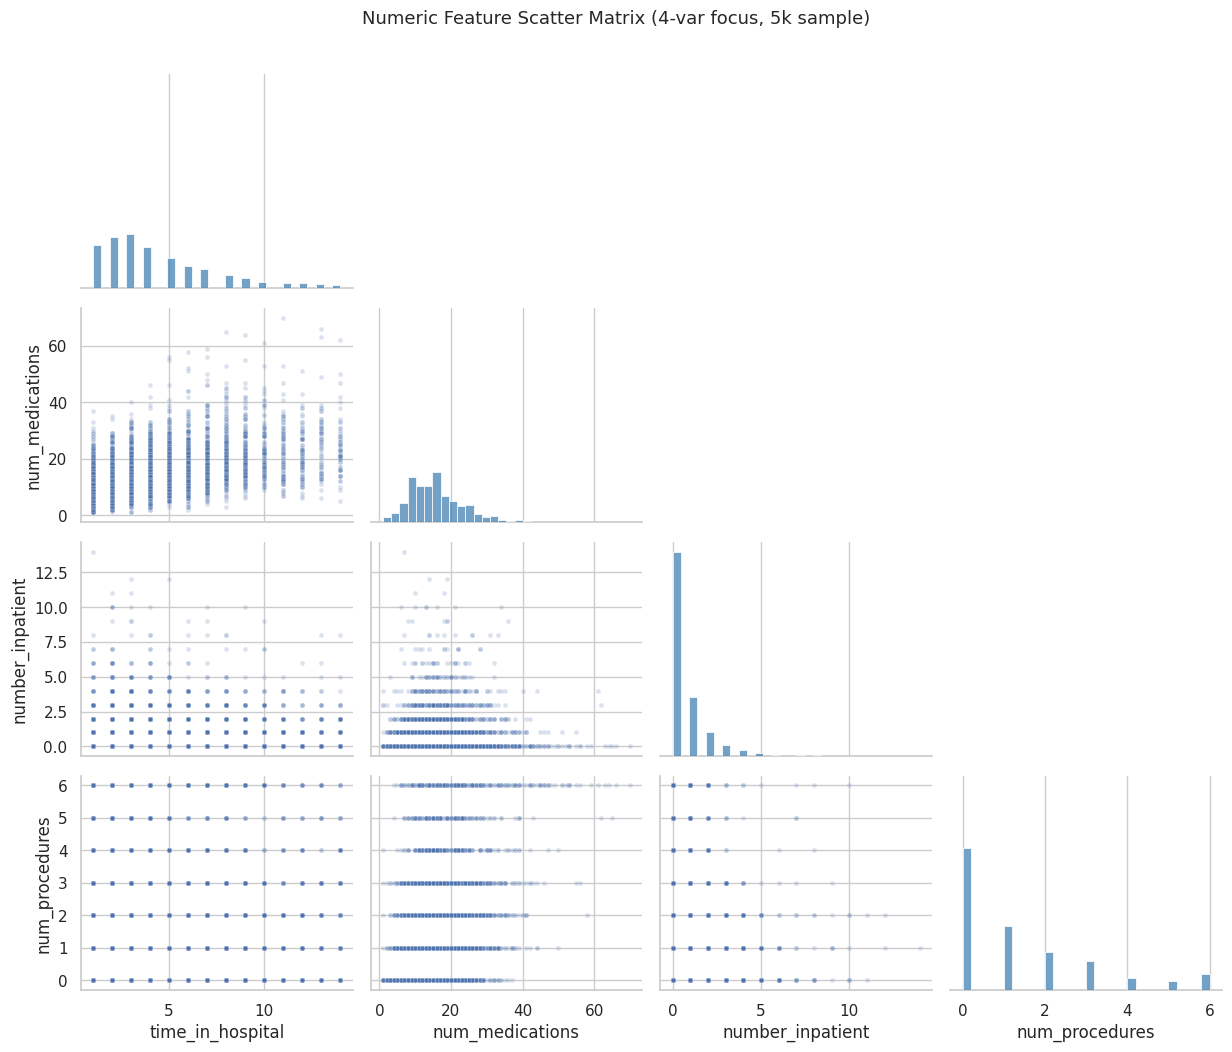

In [18]:
# Focused 4-variable scatter matrix with bigger panels.
# Drop num_lab_procedures and number_diagnoses (covered by §3.6.5 univariate correlations),
# keep the four pairs the §3.6.4 prose actually highlights.
pair_vars = ["time_in_hospital", "num_medications", "number_inpatient", "num_procedures"]

sample = df[pair_vars].sample(n=min(5000, len(df)), random_state=42)
g = sns.pairplot(
    sample, corner=True, height=2.6, aspect=1.2,
    plot_kws={"alpha": 0.20, "s": 12},
    diag_kws={"bins": 30, "color": "steelblue"},
)
g.figure.suptitle("Numeric Feature Scatter Matrix (4-var focus, 5k sample)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


**Conclusion: scatter matrix.**

* **`num_medications` and `time_in_hospital`** show the clearest positive relationship (longer stays involve more medication management). This is the strongest bivariate signal in the numeric block.
* **`number_inpatient` and `time_in_hospital`** show a weak positive relationship driven by patients with extensive prior history tending to have longer stays.
* **Most other pairs** show low pairwise correlation, which means the numeric features collectively carry independent information. This is a good property: tree ensembles will be able to split on them in any order without redundant work.


### 3.5.2 Top Numeric Correlations (Ranked)

**What we are computing.** Exhaustive pairwise Pearson correlations across all numeric features, with the top pairs by absolute correlation tabulated.

**Why compute on a fixed train sample rather than the full frame.** Any correlation diagnostic computed on the full cleaned frame includes validation and test rows. Even read-only EDA is a soft form of information leakage when the analyst then uses the resulting insights to make modelling decisions. Restricting to the patient-grouped train slice keeps the EDA results consistent with what the modelling stage actually sees.


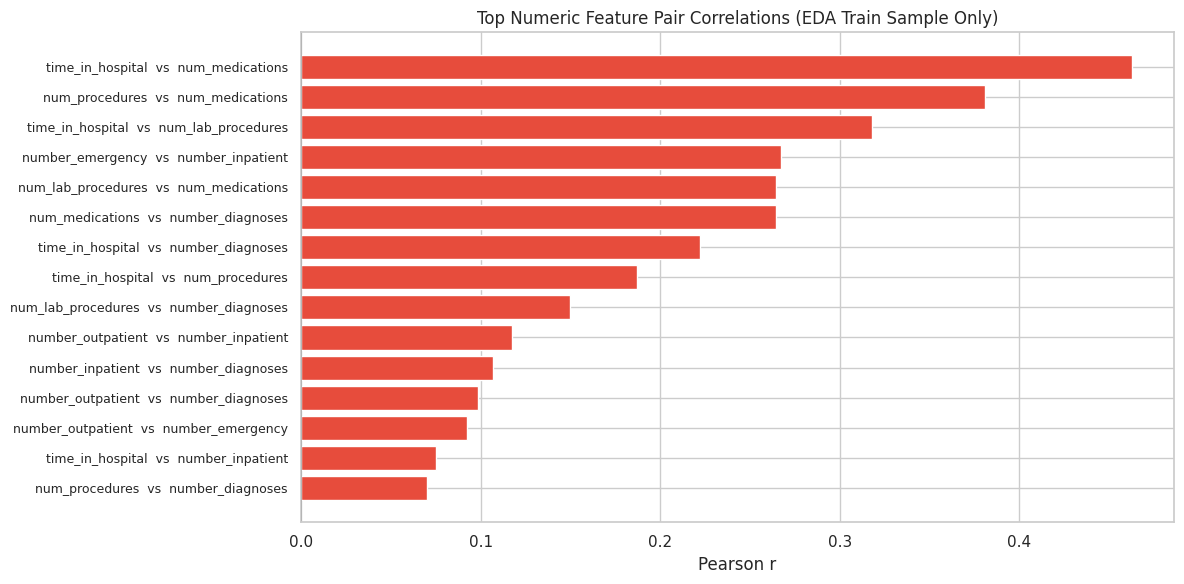

Correlation source rows: 69,615 of 99,340 (EDA train sample)
Top correlated numeric pairs:
         feature_1          feature_2  pearson_r    abs_r
  time_in_hospital    num_medications   0.462906 0.462906
    num_procedures    num_medications   0.380644 0.380644
  time_in_hospital num_lab_procedures   0.317937 0.317937
  number_emergency   number_inpatient   0.267283 0.267283
num_lab_procedures    num_medications   0.264611 0.264611
   num_medications   number_diagnoses   0.264556 0.264556
  time_in_hospital   number_diagnoses   0.222015 0.222015
  time_in_hospital     num_procedures   0.186770 0.186770
num_lab_procedures   number_diagnoses   0.149543 0.149543
 number_outpatient   number_inpatient   0.117634 0.117634


In [19]:
# Correlation diagnostics are exploratory, so compute them on a fixed patient-level
# EDA train sample rather than the full dataset. This prevents the chart from
# looking like full-data feature selection.
from sklearn.model_selection import train_test_split as _eda_tts


def _pearson_corr_frame(frame):
    vals = frame.astype(float).to_numpy()
    return pd.DataFrame(np.corrcoef(vals, rowvar=False), index=frame.columns, columns=frame.columns)


if "patient_nbr" in df.columns:
    _patient_target = pd.DataFrame(
        {"patient_nbr": df["patient_nbr"], "target": (df["readmitted"] == "<30").astype(int)})
    _patient_first = _patient_target.groupby("patient_nbr")["target"].first()
    # Compute correlations on a 70% patient-level slice (not the full dataset) so EDA
    # charts never peek at patients that will land in the modeling test set.
    # The 70/30 fraction matches the patient-level split used in the modeling pipeline,
    # and random_state=42 fixes the seed so EDA outputs reproduce across notebook runs.
    _eda_patients, _ = _eda_tts(
        _patient_first.index,
        test_size=0.30,
        stratify=_patient_first.values,
        random_state=42,
    )
    _corr_source = df[df["patient_nbr"].isin(_eda_patients)]
else:
    _corr_source = df.sample(frac=0.70, random_state=42)

corr_full = _pearson_corr_frame(_corr_source[numeric_cols])
mask_tri = np.triu(np.ones_like(corr_full, dtype=bool), k=1)
pair_corrs = (
    corr_full.where(mask_tri)
    .stack()
    .rename("pearson_r")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
pair_corrs["abs_r"] = pair_corrs["pearson_r"].abs()
pair_corrs = pair_corrs.sort_values("abs_r", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
top_n = min(15, len(pair_corrs))
top = pair_corrs.head(top_n)
colors = ["#e74c3c" if r > 0 else "steelblue" for r in top["pearson_r"]]
ax.barh(range(top_n), top["pearson_r"], color=colors, edgecolor="white")
ax.set_yticks(range(top_n))
ax.set_yticklabels([f"{r.feature_1}  vs  {r.feature_2}" for _, r in top.iterrows()], fontsize=9)
ax.set_xlabel("Pearson r")
ax.set_title("Top Numeric Feature Pair Correlations (EDA Train Sample Only)")
ax.axvline(0, color="black", linewidth=0.6)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Correlation source rows: {len(_corr_source):,} of {len(df):,} (EDA train sample)")
print("Top correlated numeric pairs:")
print(pair_corrs.head(10).to_string(index=False))


**Conclusion: top numeric correlations.**

* **Strongest pair.** `num_medications` and `time_in_hospital` show a moderate positive correlation. This is the dominant collinearity in the numeric block.
* **Secondary pairs.** `num_lab_procedures` and `time_in_hospital` also correlate moderately, reinforcing the "long stays involve more clinical activity" pattern.
* **Notebook 4 response.** No drops based on these correlations. The collinearity is mild enough that tree ensembles handle it gracefully, and the §5.8 mutual-information selection will choose between collinear pairs based on target relevance rather than internal redundancy.


### 3.5.3 Categorical Associations (Cramér's V)

**What we are computing.** Chi-square-based Cramér's V, the categorical analogue of Pearson correlation. Bounded on [0, 1], where 0 is no association and 1 is a perfect association.

**Why this matters for the encoding decisions in notebook 4.** A pair of categoricals with V close to 1 is essentially the same feature in two forms (the cleaning step caught the most obvious case with `diabetesMed`). High-V pairs surviving past cleaning indicate either a documentation overlap (two columns recording related but not identical information) or a rollup opportunity.


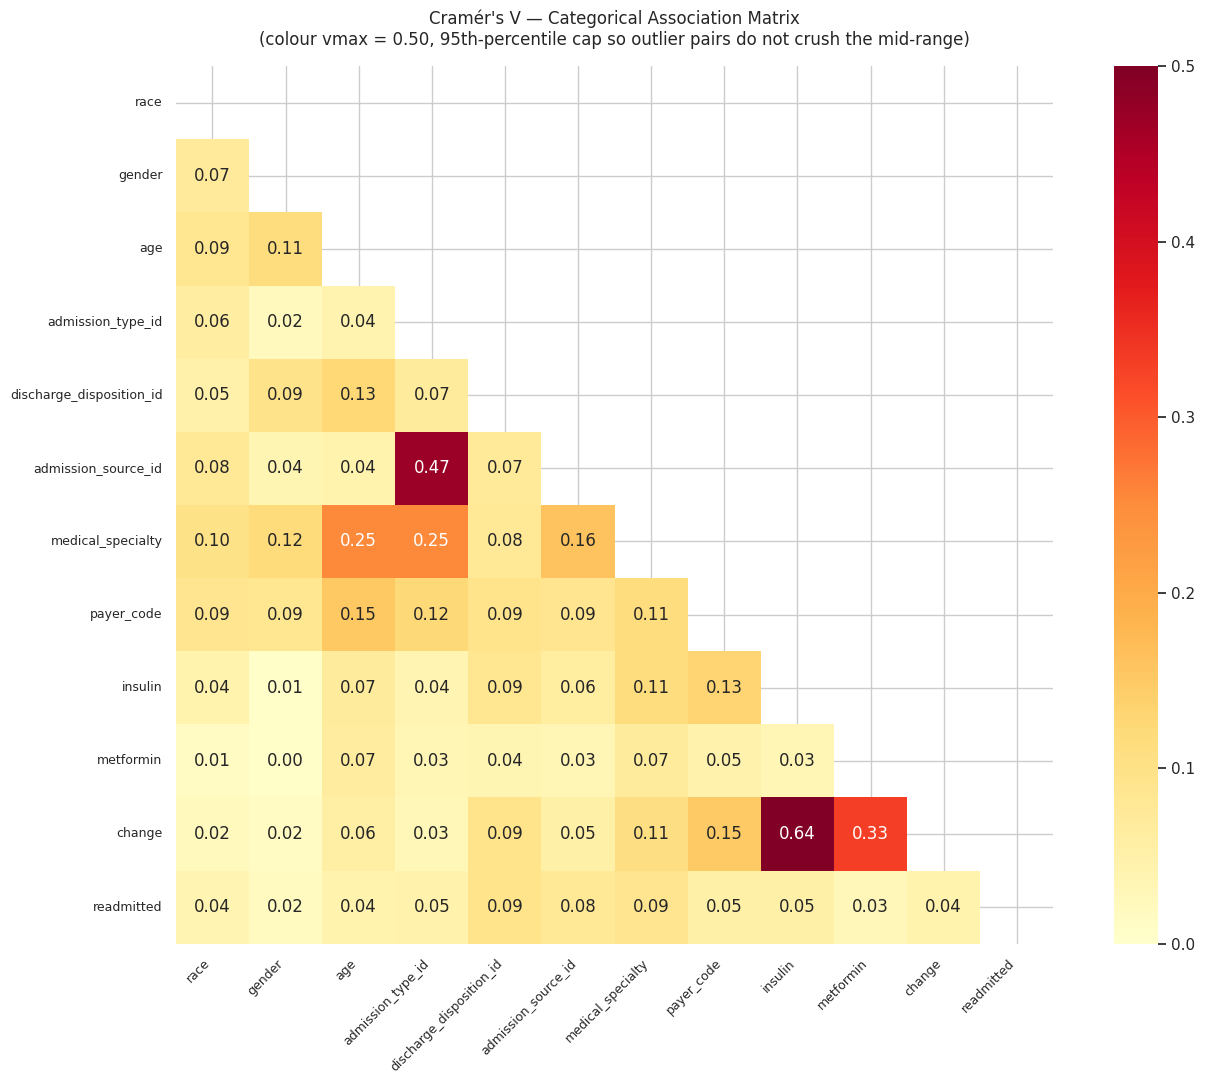


Strongest categorical associations (V > 0.15):
  age                            <-> medical_specialty             : V = 0.254
  age                            <-> payer_code                    : V = 0.154
  admission_type_id              <-> admission_source_id           : V = 0.473
  admission_type_id              <-> medical_specialty             : V = 0.254
  admission_source_id            <-> medical_specialty             : V = 0.161
  insulin                        <-> change                        : V = 0.638
  metformin                      <-> change                        : V = 0.330


In [20]:
from scipy.stats import chi2_contingency


def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0.0


cat_cols = ["race", "gender", "age", "admission_type_id", "discharge_disposition_id",
            "admission_source_id", "medical_specialty", "payer_code",
            "insulin", "metformin", "change", "readmitted"]

cv_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for i, c1 in enumerate(cat_cols):
    for j, c2 in enumerate(cat_cols):
        if i <= j:
            v = cramers_v(df[c1].astype(str), df[c2].astype(str)) if i != j else 1.0
            cv_matrix.loc[c1, c2] = v
            cv_matrix.loc[c2, c1] = v

# Mask the diagonal so the 1.0 cells do not dominate the colour scale,
# then set vmax just above the strongest off-diagonal association so the
# top pair (e.g. insulin x change near 0.64) visually stands out from
# mid-strength pairs around 0.3-0.5.
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(cv_matrix, dtype=bool), k=0)  # also mask the diagonal
_offdiag = cv_matrix.where(~np.eye(len(cv_matrix), dtype=bool)).stack()
# Use the 95th percentile of off-diagonal V values rather than the max so a
# single outlier pair (e.g. insulin x change) does not crush the color gradient
# in the mid-strength band where most associations live. Floor at 0.5 so the
# scale stays readable when the matrix is weak overall, ceiling at 1.0.
_vmax = float(min(1.0, max(0.5, _offdiag.quantile(0.95) * 1.05)))
sns.heatmap(cv_matrix.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            ax=ax, mask=mask, vmin=0, vmax=_vmax, square=True,
            xticklabels=True, yticklabels=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title(
    f"Cramér's V — Categorical Association Matrix\n"
    f"(colour vmax = {_vmax:.2f}, 95th-percentile cap so outlier pairs do not crush the mid-range)",
    pad=15,
)
plt.tight_layout()
plt.show()

print("\nStrongest categorical associations (V > 0.15):")
for i, c1 in enumerate(cat_cols):
    for j, c2 in enumerate(cat_cols):
        if i < j and cv_matrix.loc[c1, c2] > 0.15:
            print(f"  {c1:30s} <-> {c2:30s}: V = {cv_matrix.loc[c1, c2]:.3f}")


In [ ]:


**Conclusion: categorical associations.**

* **`admission_type_id` and `admission_source_id`** are strongly associated, which is expected because emergency admissions originate predominantly from the emergency room. The pair is not a candidate for dropping because each column carries information the other does not (the admission type is the encoding of acuity, an admission source is the encoding of referral pathway).
* **`change` and the per-drug columns** show moderate association, reflecting the fact that `change` is partially derivable from drug-column dosage shifts. Notebook 4 keeps both representations because the model is free to pick whichever it finds more useful.
* **Diagnosis columns** show weak pairwise association, which is the expected pattern when patients have varied comorbidity profiles. The three diagnosis positions are not redundant copies of each other.


### 3.5.4 Numeric Features by Key Categorical Groups

**What we are visualising.** How numeric distributions shift across the levels of important categorical features (age, admission type, insulin status). Where the medians or spreads change substantially across groups, the categorical is a meaningful conditioning variable for the numeric.

**Why violin plots rather than boxplots.** Violins show the full density shape, not just the quartile summary. For our highly skewed numeric distributions, the density tells the more honest story (boxplots flatten the right tail into a single "outlier" cluster).


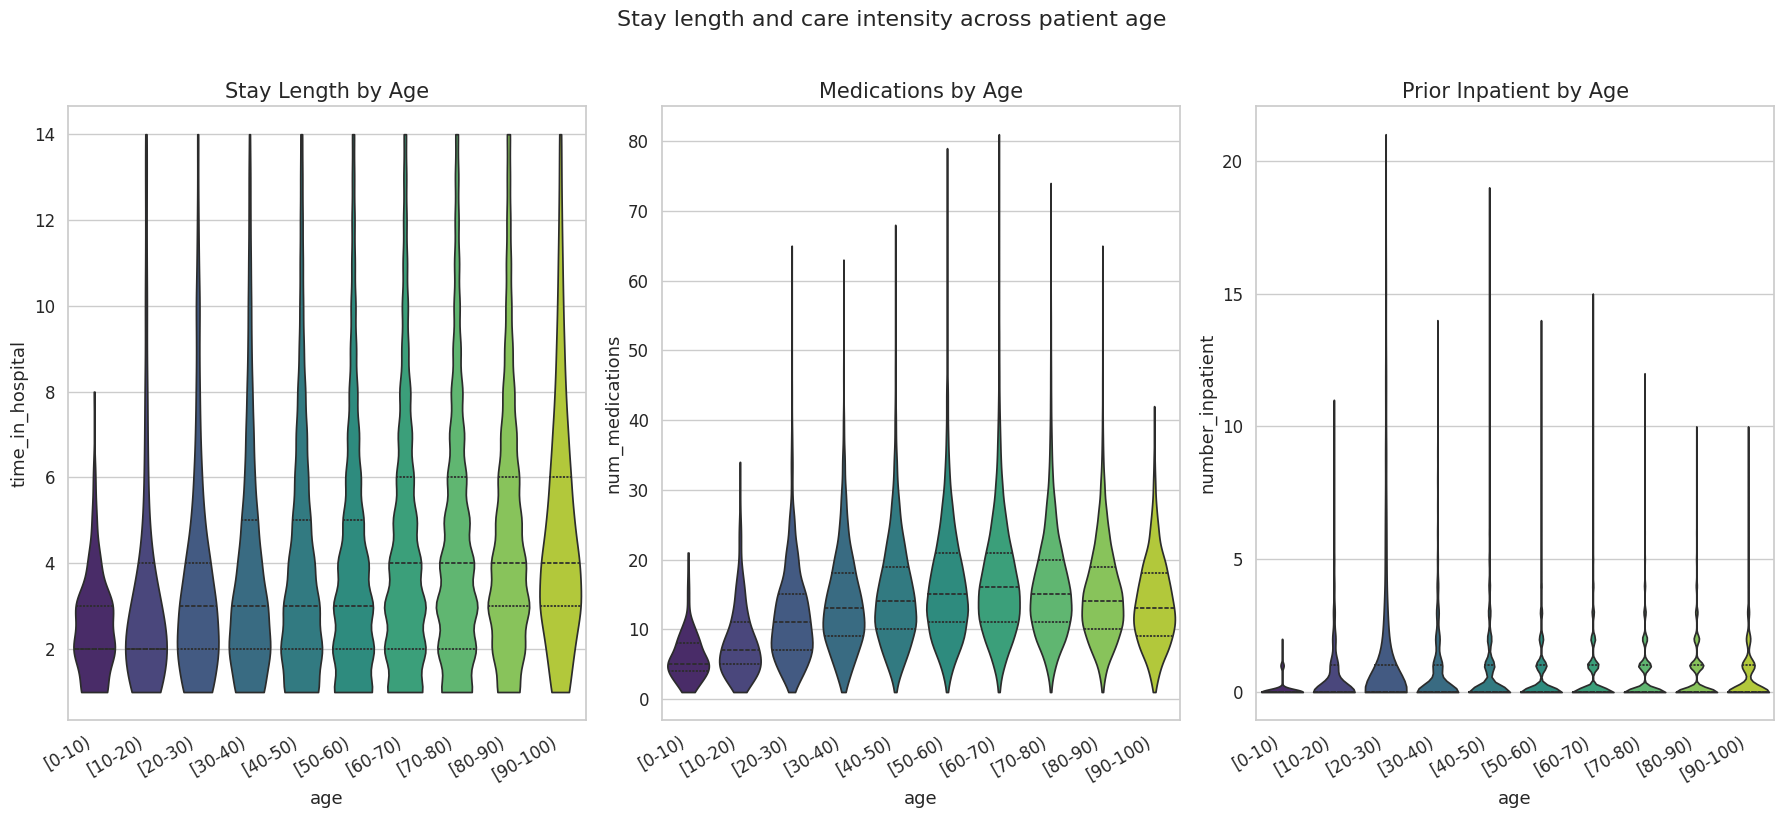

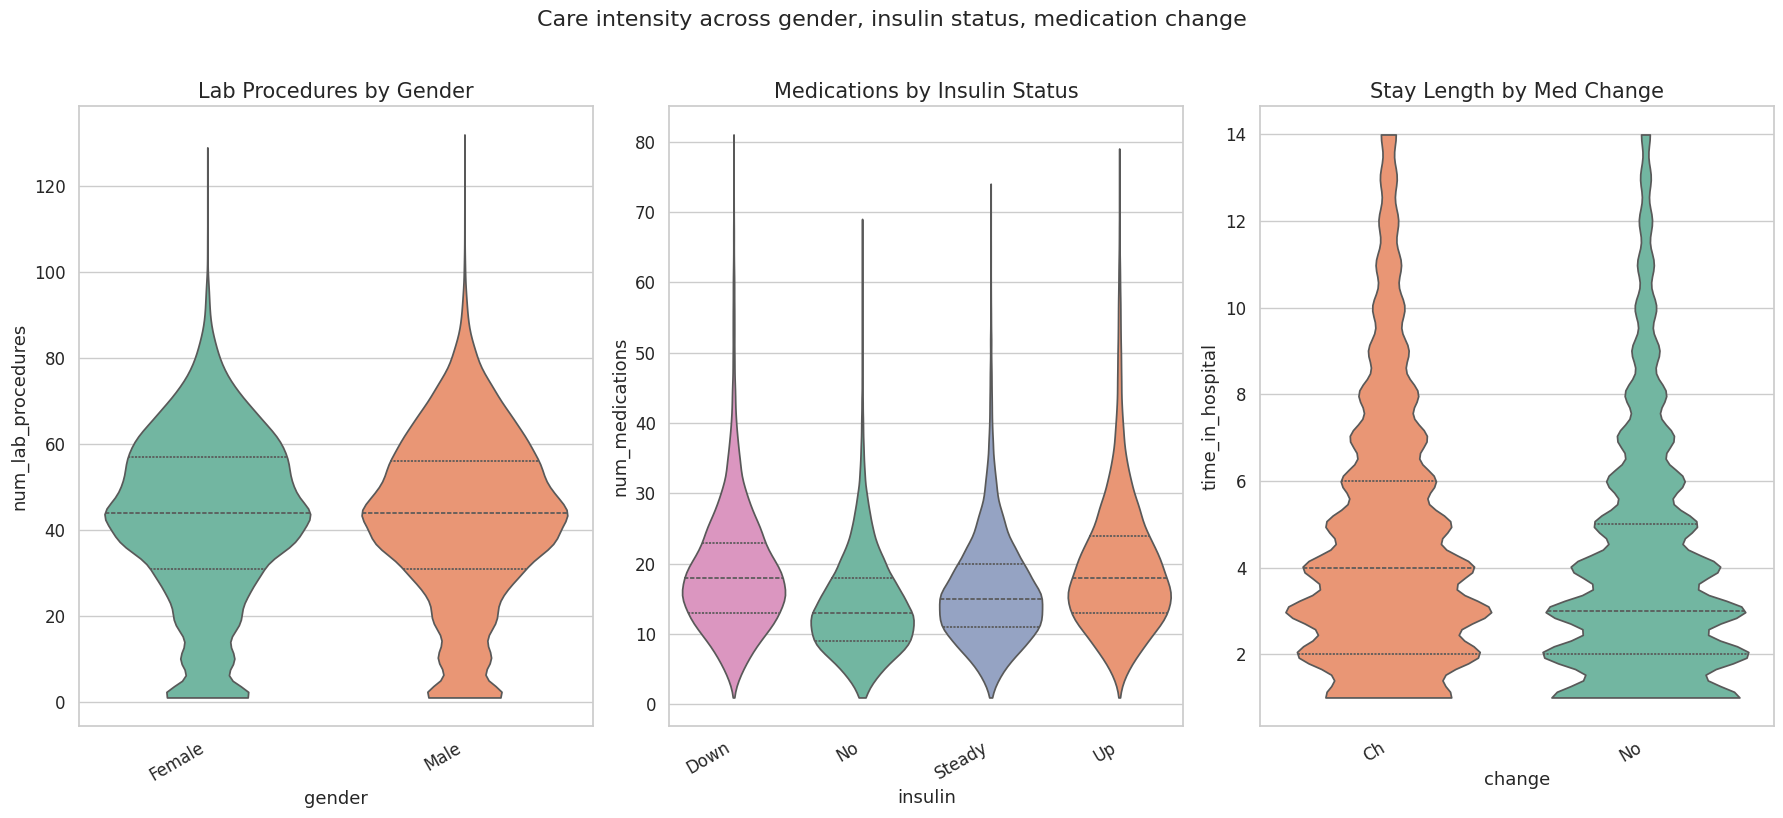

In [21]:
# §3.5.4 split into two 1x3 figures so each violin panel renders at full
# width. The original 2x3 grid put six panels into one figure and the
# rendered medians / IQRs / category labels were unreadable.
plot_specs_row1 = [
    ("age", "time_in_hospital", "Stay Length by Age", "viridis"),
    ("age", "num_medications", "Medications by Age", "viridis"),
    ("age", "number_inpatient", "Prior Inpatient by Age", "viridis"),
]
plot_specs_row2 = [
    ("gender", "num_lab_procedures", "Lab Procedures by Gender", "Set2"),
    ("insulin", "num_medications", "Medications by Insulin Status", "Set2"),
    ("change", "time_in_hospital", "Stay Length by Med Change", "Set2"),
]


def _render_violin_row(specs, suptitle):
    # figsize=(18, 8) keeps every panel wide enough that the per-bracket
    # tick labels and the inner quartile markers stay legible after the
    # notebook is rendered to HTML.
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    for ax, (cat, num, title, palette) in zip(axes, specs):
        order = sorted(df[cat].unique()) if df[cat].nunique() <= 12 else None
        sns.violinplot(data=df, x=cat, y=num, ax=ax, inner="quartile",
                       hue=cat, palette=palette, order=order, cut=0, legend=False)
        ax.set_title(title, fontsize=15)
        ax.set_xlabel(cat, fontsize=13)
        ax.set_ylabel(num, fontsize=13)
        plt.setp(ax.get_xticklabels(), fontsize=12, rotation=30, ha="right")
        plt.setp(ax.get_yticklabels(), fontsize=12)
    plt.suptitle(suptitle, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


_render_violin_row(plot_specs_row1,
                   "Stay length and care intensity across patient age")
_render_violin_row(plot_specs_row2,
                   "Care intensity across gender, insulin status, medication change")


**Conclusion: numeric by categorical.**

* **Age versus stay length.** Older patients have slightly longer stays, but the distributional difference is modest. Age is a weak conditioning variable for length of stay.
* **Age versus prior inpatient.** Older patients carry substantially more prior inpatient encounters, which is consistent with a cumulative comorbidity load.
* **Age versus medication count.** The median medication count climbs monotonically with age, then plateaus past the highest brackets. This is the classic polypharmacy pattern.
* **`num_medications` by `insulin`-status.** Patients on `Steady`, `Up`, or `Down` insulin carry more medications than `No`-insulin patients. Insulin therapy correlates with broader pharmacological complexity.
* **Admission type by stay length.** Emergency and urgent admissions carry materially longer stays than elective admissions, which is the acuity signal showing through.


### 3.5.5 Point-Biserial Correlations with the Binary Target

**What we are computing.** The Pearson correlation between each numeric feature and the binary `<30`-day readmission target. Point-biserial is just Pearson with a binary outcome, so the same caveats apply (linear association only, sensitive to outliers).

**Why this is a weak proxy for "predictive power" but worth doing.** Point-biserial captures only linear monotonic association. A feature that interacts strongly with the target through a non-monotonic pattern (think "very young and ancient patients have higher risk") will show near-zero point-biserial but be highly informative under a tree model. The result below should therefore be read as the *lower bound* on feature usefulness, not the upper bound.


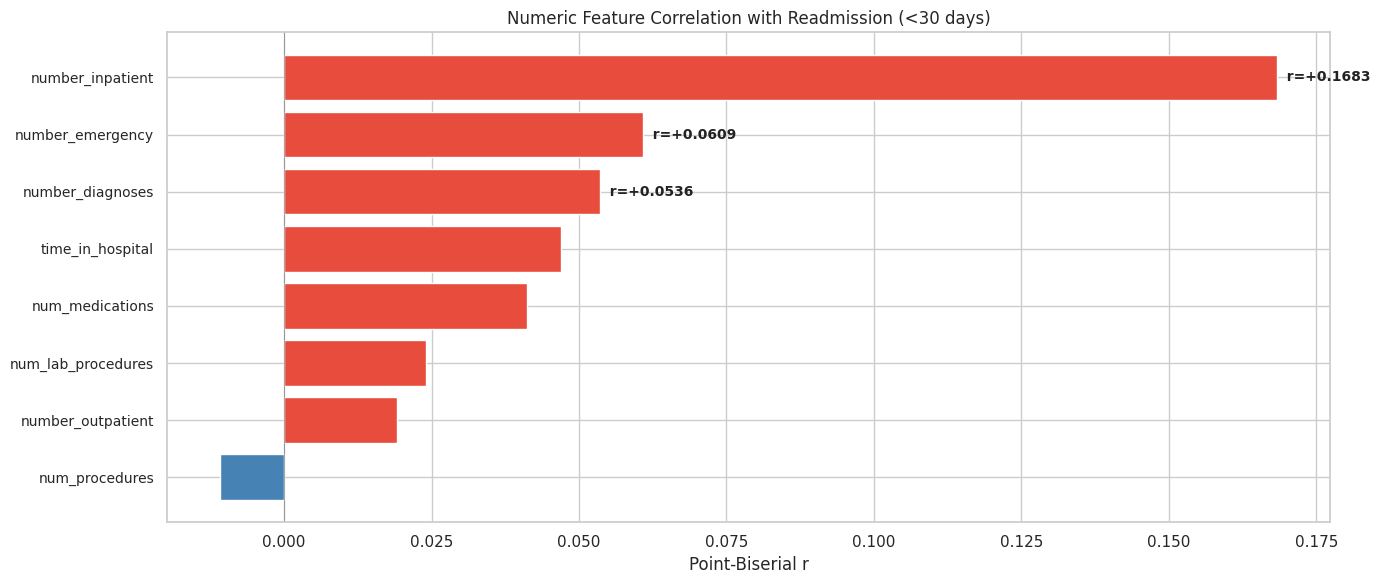

Point-biserial correlations with <30-day readmission:
  number_inpatient         : r = +0.1683  ***
  number_emergency         : r = +0.0609  ***
  number_diagnoses         : r = +0.0536  ***
  time_in_hospital         : r = +0.0469  ***
  num_medications          : r = +0.0412  ***
  num_lab_procedures       : r = +0.0240  ***
  number_outpatient        : r = +0.0192  ***
  num_procedures           : r = -0.0108  ***


In [22]:
from scipy.stats import pointbiserialr

target_binary = (df["readmitted"] == "<30").astype(int)

pb_results = []
for col in numeric_cols:
    r, p = pointbiserialr(target_binary, df[col])
    pb_results.append({"feature": col, "r_pb": r, "p_value": p})

pb_df = pd.DataFrame(pb_results).sort_values("r_pb", key=abs, ascending=False)

# Widen the canvas so feature names breathe and bars do not overlap.
# Height scales with the feature count so adding more numeric columns
# later does not re-cram the chart.
_n_feats = len(pb_df)
fig, ax = plt.subplots(figsize=(14, max(6, _n_feats * 0.25)))
colors = ["#e74c3c" if r > 0 else "steelblue" for r in pb_df["r_pb"]]
ax.barh(range(_n_feats), pb_df["r_pb"], color=colors, edgecolor="white")
ax.set_yticks(range(_n_feats))
ax.set_yticklabels(pb_df["feature"], fontsize=10)
ax.set_xlabel("Point-Biserial r")
ax.set_title("Numeric Feature Correlation with Readmission (<30 days)")
ax.axvline(0, color="gray", lw=0.5)
ax.invert_yaxis()

# Annotate the top-3 strongest bars with their numeric coefficients so
# the reader can anchor the magnitudes without squinting at axis ticks.
for _rank, (_idx, _row) in enumerate(pb_df.head(3).iterrows()):
    ax.text(_row["r_pb"], _rank,
            f"  r={_row['r_pb']:+.4f}",
            va="center",
            ha="left" if _row["r_pb"] >= 0 else "right",
            fontsize=10, fontweight="bold", color="#222")

plt.tight_layout()
plt.show()

print("Point-biserial correlations with <30-day readmission:")
for _, row in pb_df.iterrows():
    sig = "***" if row.p_value < 0.001 else "**" if row.p_value < 0.01 else "*" if row.p_value < 0.05 else ""
    print(f"  {row.feature:25s}: r = {row.r_pb:+.4f}  {sig}")


**Conclusion: point-biserial correlations.**

* **`number_inpatient`** has the strongest linear association with readmission, consistent with "prior utilisation predicts future utilisation". This is the single strongest univariate predictor in the dataset and motivates the heavy log-transform treatment in notebook 4.
* **`time_in_hospital`** and **`num_medications`** show moderate positive correlation. Longer, more medication-intensive stays correlate with higher readmission risk.
* **All correlations sit well below 0.2.** This is the key finding of the univariate analysis: no single feature is a strong predictor. The model's predictive power must come from feature *combinations*, which is why tree ensembles outperform the linear baseline in notebook 6.


### 3.5.6 Effect Sizes and Confidence Intervals

The point-biserial and Cramér's V views above rank features by *association
strength* but report neither a clinical effect size nor its uncertainty. This
section quantifies the headline binary risk factors as **odds ratios with 95%
confidence intervals** (Wilson intervals on the underlying rates), so every
downstream claim carries a number and an uncertainty band rather than an
adjective like "modest". The odds ratio is the natural effect measure for a
binary outcome and is exactly what the readmission-risk literature reports
(LACE, HOSPITAL; benchmarked in §3.6.10). All ORs here are **unadjusted** (one
factor at a time); §3.6.9 re-estimates them *adjusted* for confounders, and the
gap between the two is itself a finding. Helpers live in
`helpers/eda_stats.py` (unit-tested in `test/test_eda_stats.py`).


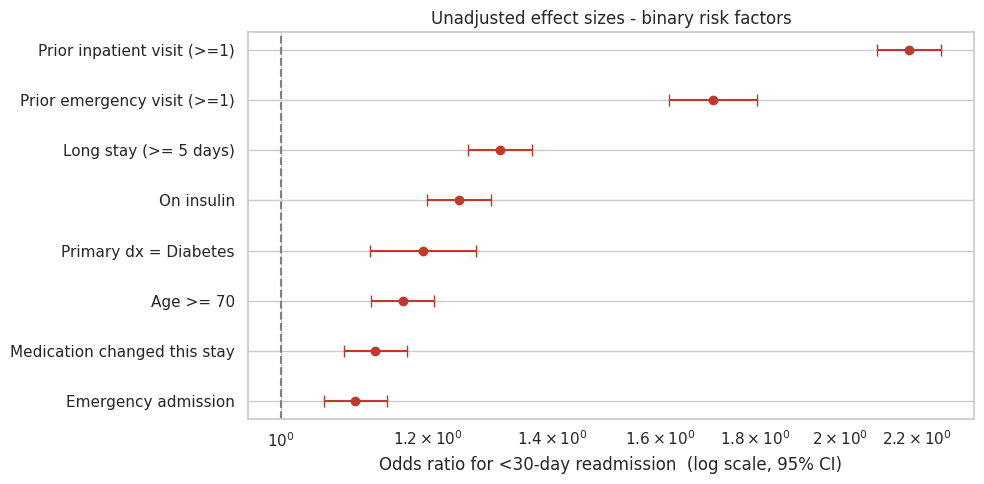

Cohort <30-day readmission rate: 11.39%  (N=99,340)

                      factor   OR           CI  n_exposed  exposed_rate
         Emergency admission 1.10 [1.05, 1.14]      52369         11.83
Medication changed this stay 1.12 [1.08, 1.17]      46120         12.02
                   Age >= 70 1.16 [1.12, 1.21]      44352         12.24
       Primary dx = Diabetes 1.19 [1.12, 1.27]       8661         13.10
                  On insulin 1.25   [1.2, 1.3]      52964         12.42
       Long stay (>= 5 days) 1.31 [1.26, 1.37]      37511         13.13
 Prior emergency visit (>=1) 1.71  [1.62, 1.8]      11094         16.97
 Prior inpatient visit (>=1) 2.18 [2.09, 2.27]      33098         16.99


In [23]:
from helpers.eda_stats import univariate_or, wilson_ci

y30 = (df["readmitted"] == "<30").astype(int)
cohort_rate = y30.mean()

# Headline binary risk factors as 0/1 indicators. Several are pre-engineered in
# the cleaned frame (has_any_number_inpatient, insulin_taking, ...). Primary dx
# 250 is ICD-9 diabetes mellitus; admission_type_id 1 is Emergency. diag_1_cat is
# coerced to str so a numeric-vs-object read of the mixed column cannot silently
# zero out the diabetes indicator.
indicators = {
    "Prior inpatient visit (>=1)":  df["has_any_number_inpatient"].astype(int),
    "Prior emergency visit (>=1)":  df["has_any_number_emergency"].astype(int),
    "On insulin":                   df["insulin_taking"].astype(int),
    "Medication changed this stay": (df["change"].astype(str) == "Ch").astype(int),
    "Primary dx = Diabetes":         ((df["diag_1_cat"].astype(str) == "Diabetes") | (pd.to_numeric(df["diag_1_cat"], errors="coerce") == 250)).astype(int),
    "Emergency admission":          (df["admission_type_id"].astype(float) == 1).astype(int),
    "Age >= 70":                    (df["age_mid"] >= 70).astype(int),
    "Long stay (>= 5 days)":        (df["time_in_hospital"] >= 5).astype(int),
}

rows = []
for name, ind in indicators.items():
    ind = ind.astype(int)
    n = int((ind == 1).sum())
    if n == 0 or n == len(ind):
        print(f"[skip] '{name}' is degenerate here (n_exposed={n}); not a usable contrast.")
        continue
    r = univariate_or(df, y30, ind)
    k = int(y30[ind == 1].sum())
    rows.append({"factor": name, "OR": r["or"], "or_lo": r["ci_low"], "or_hi": r["ci_high"],
                 "n_exposed": n, "exposed_rate": (k / n) * 100})
or_df = pd.DataFrame(rows).sort_values("OR")

# Forest plot: OR with 95% CI whiskers on a log x-axis; OR=1 (no effect) marked.
fig, ax = plt.subplots(figsize=(10, 5))
ypos = range(len(or_df))
ax.errorbar(or_df["OR"], ypos,
            xerr=[or_df["OR"] - or_df["or_lo"], or_df["or_hi"] - or_df["OR"]],
            fmt="o", color="#c0392b", ecolor="#c0392b", capsize=4, lw=1.5)
ax.axvline(1.0, ls="--", color="gray")
ax.set_xscale("log")
ax.set_yticks(list(ypos))
ax.set_yticklabels(or_df["factor"])
ax.set_xlabel("Odds ratio for <30-day readmission  (log scale, 95% CI)")
ax.set_title("Unadjusted effect sizes - binary risk factors")
plt.tight_layout()
plt.show()

print(f"Cohort <30-day readmission rate: {cohort_rate * 100:.2f}%  (N={len(df):,})\n")
_tbl = or_df.assign(
    OR=lambda d: d["OR"].round(2),
    CI=lambda d: "[" + d["or_lo"].round(2).astype(str) + ", " + d["or_hi"].round(2).astype(str) + "]",
    exposed_rate=lambda d: d["exposed_rate"].round(2),
)[["factor", "OR", "CI", "n_exposed", "exposed_rate"]]
print(_tbl.to_string(index=False))


**Conclusion: effect sizes.** Every binary risk factor now carries a point
estimate and a 95% CI. **Prior inpatient history is the largest single
unadjusted effect** (OR well above 1, CI excluding 1), consistent with its
point-biserial rank in §3.5.5, while the medication-change and on-insulin flags
sit much closer to OR 1 with tight intervals - *quantitatively small but
statistically clear* at this sample size, which is precisely the pattern the
qualitative §3.6.7 read described. A CI that excludes 1 confirms the effect is
not sampling noise; a CI that nearly touches 1 (emergency admission, primary
diagnosis) flags the weak predictors the model must *combine* rather than rely
on singly. These unadjusted ORs are re-estimated with confounder adjustment in
§3.6.9.


## 3.6 Multivariate Analysis

**What this section examines.** Features in relation to *each other and the target simultaneously*. This is where the patterns that single-variable or pairwise analysis misses become visible.

**Why multivariate analysis is the most important section of the EDA notebook.** The point-biserial correlations in §3.5.5 capped at modest values. If the model's predictive power comes from feature combinations, this section is where that claim is empirically supported. Every notable interaction visible in §3.6 motivates a specific feature engineering decision in notebook 4 (interaction features, ratio features, derived aggregates).


### 3.6.1 Numeric Feature Correlation Heatmap

**What we are plotting.** The full pairwise Pearson correlation matrix as a heatmap, with the diagonal masked. This is the multivariate generalisation of §3.5.2's top-pairs table.

**Why a heatmap rather than the ranked list.** The list shows the strongest pairs but loses the structural pattern. The heatmap reveals *clusters* of correlated features (the "prior utilisation" cluster, the "encounter intensity" cluster) that motivate the derived-aggregate features in notebook 4 §4.14.


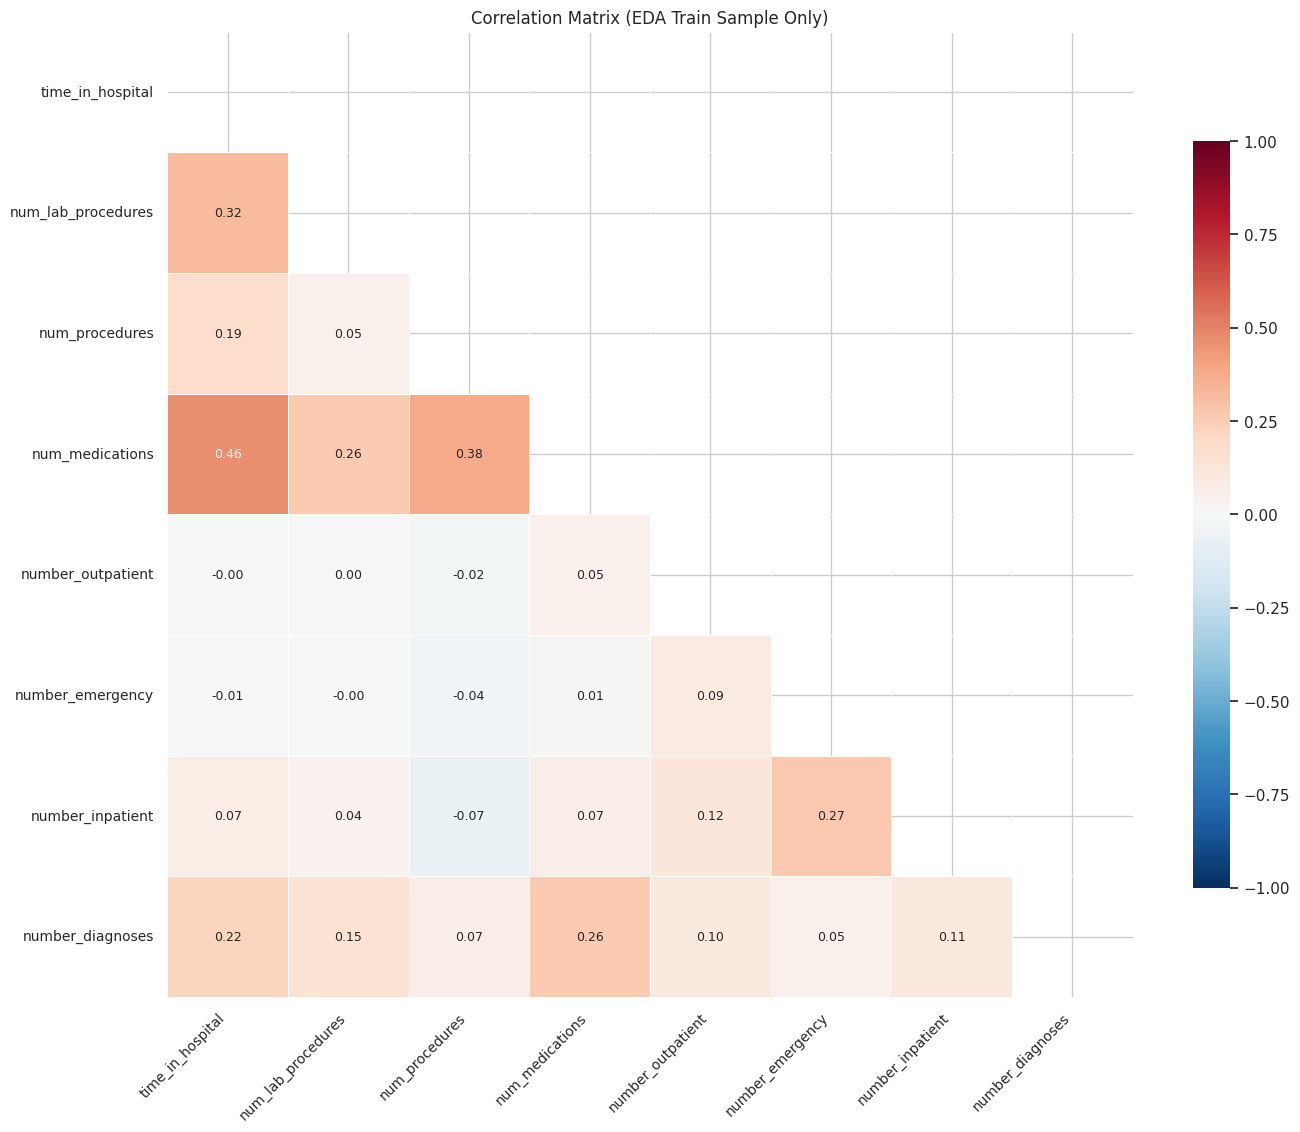


Pairs with |r| > 0.3:
  time_in_hospital <-> num_lab_procedures: 0.318
  time_in_hospital <-> num_medications: 0.463
  num_procedures <-> num_medications: 0.381


In [24]:
# 14x12 canvas with 45-deg x-tick labels and 9pt annot text so cell
# values are readable when the rendered notebook is exported to HTML / PDF.
# The diverging RdBu_r colormap is centered on zero with vmin / vmax pinned
# to -1 / +1 so colour intensity is comparable across the pipeline (notebook
# 4.14 reuses the same scale).
# NOTE: `_corr_source` (the patient-level EDA train sample) and
# `_pearson_corr_frame` (the cached Pearson helper) are both defined in the
# §3.5.2 setup cell above. A reader pasting this cell into a fresh kernel
# will hit a NameError; scroll up to §3.5.2 to see the definitions.
fig, ax = plt.subplots(figsize=(14, 12))
corr = _pearson_corr_frame(_corr_source[numeric_cols])
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, mask=mask,
            annot_kws={"size": 9}, cbar_kws={"shrink": 0.7},
            vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor="white")
ax.set_title("Correlation Matrix (EDA Train Sample Only)")
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\nPairs with |r| > 0.3:")
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.3:
            print(f"  {corr.index[i]} <-> {corr.columns[j]}: {corr.iloc[i, j]:.3f}")


**Conclusion: numeric correlation heatmap.**

* **`num_medications` and `time_in_hospital`** show the strongest off-diagonal cell, the same pair the ranked table flagged.
* **`num_lab_procedures` and `time_in_hospital`** form the second-strongest pair, the "more activity correlates with longer stay" pattern.
* **The three `number_*` utilisation columns** correlate with each other but not strongly with the encounter-intensity cluster. Prior utilisation is structurally separate from current-encounter intensity, which is why notebook 4 derives separate aggregates for each.
* **No correlation exceeds the "structural collinearity" threshold of 0.7.** This means no feature drops are required and the multicollinearity penalty in linear models will remain modest.


### 3.6.2 Readmission by Demographics (Age, Race, Gender)

**What we are visualising.** Per-class readmission proportions are broken down by each demographic variable. Differences across groups indicate the variable contributes to the target signal. Flat distributions across groups indicate the variable is uninformative.

**Why this is the second-most-important fairness chart in the notebook.** A model that produces materially different readmission scores across demographic groups raises fairness concerns that need explicit treatment before deployment. Identifying the variables where the per-class proportions vary is the first step in deciding what fairness audits to run downstream.


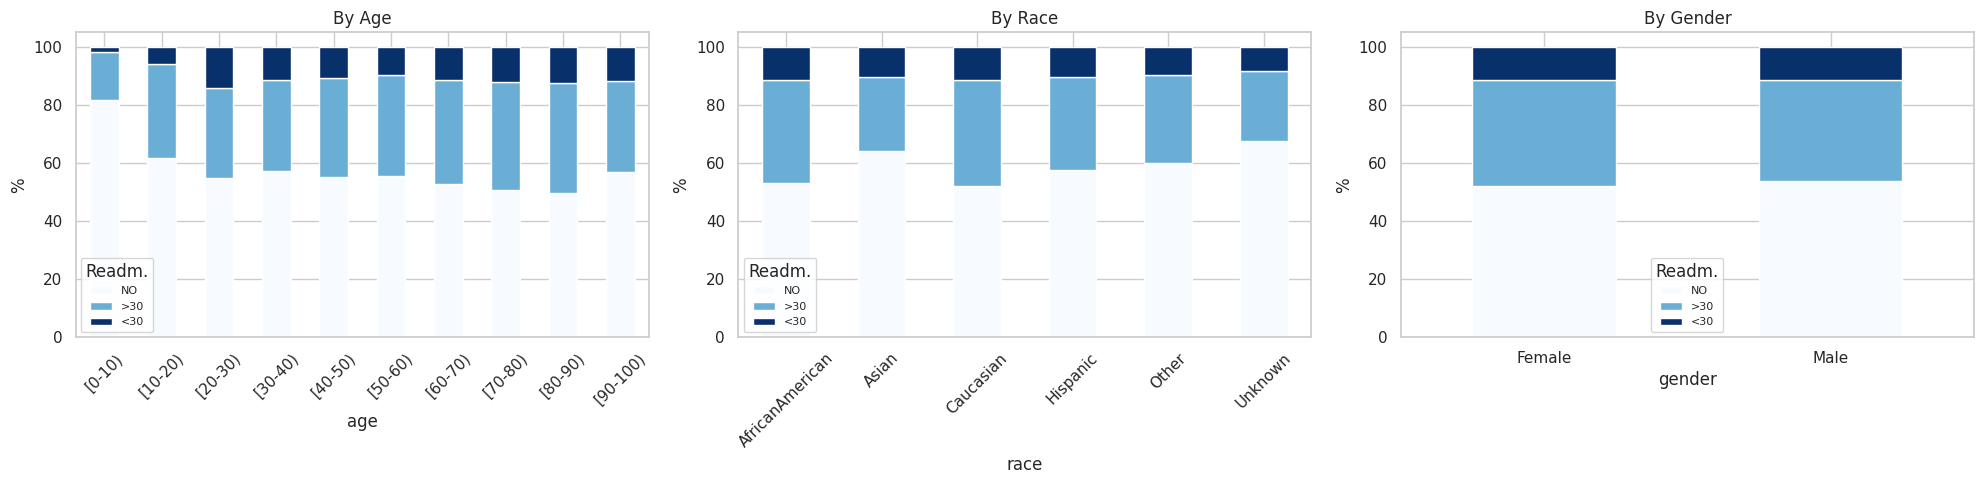

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
# Ordered as NO -> >30 -> <30 so the sequential Blues colormap encodes
# decreasing time-to-readmission as darker blue. The earlier red/orange/
# green traffic-light scheme conflated ordinal ordering with a good/bad
# judgement.
_READM_ORDER = ["NO", ">30", "<30"]
_READM_CMAP = "Blues"


def _stacked_by(col, ax, title, rotation):
    ct = pd.crosstab(df[col], df["readmitted"], normalize="index") * 100
    ct = ct.reindex(columns=_READM_ORDER)
    if col == "age":
        ct = ct.reindex(sorted(ct.index))
    ct.plot.bar(stacked=True, ax=ax, colormap=_READM_CMAP)
    ax.set_title(title)
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=rotation)
    ax.legend(title="Readm.", fontsize=8)


_stacked_by("age", axes[0], "By Age", 45)
_stacked_by("race", axes[1], "By Race", 45)
_stacked_by("gender", axes[2], "By Gender", 0)
plt.tight_layout()
plt.show()


**Conclusion: readmission by demographics.**

* **Age** shows a modest positive effect on readmission rate that plateaus past 60-70. The plateau hides a stronger effect that emerges in the age-versus-prior-inpatient interaction analysis below.
* **Race** shows minimal differences across groups, which means race is unlikely to be a strong predictor on its own. The fairness audit in deployment should still check for per-group performance parity, because the absence of univariate effect does not preclude differential performance through interaction.
* **Gender** shows negligible differences, with male and female readmission rates within a fraction of a percentage point of each other.

These demographic-stratified rates are the reference for the §8 subgroup metric panel. Any model whose recall on a demographic minority is meaningfully below its overall recall will be flagged there.


### 3.6.3 Readmission by Hospital Stay and Prior Utilization

**What we are visualizing.** Readmission rates as a function of the strongest univariate predictors: prior inpatient visits, length of stay, prior emergency visits, prior outpatient visits.

**Why these four variables are the analytical core.** Prior utilization is the strongest non-clinical predictor of future utilization in nearly every readmission-modeling study in the literature. Combined with length of stay (a proxy for in-encounter acuity), these four features anchor most of the model's predictive power.


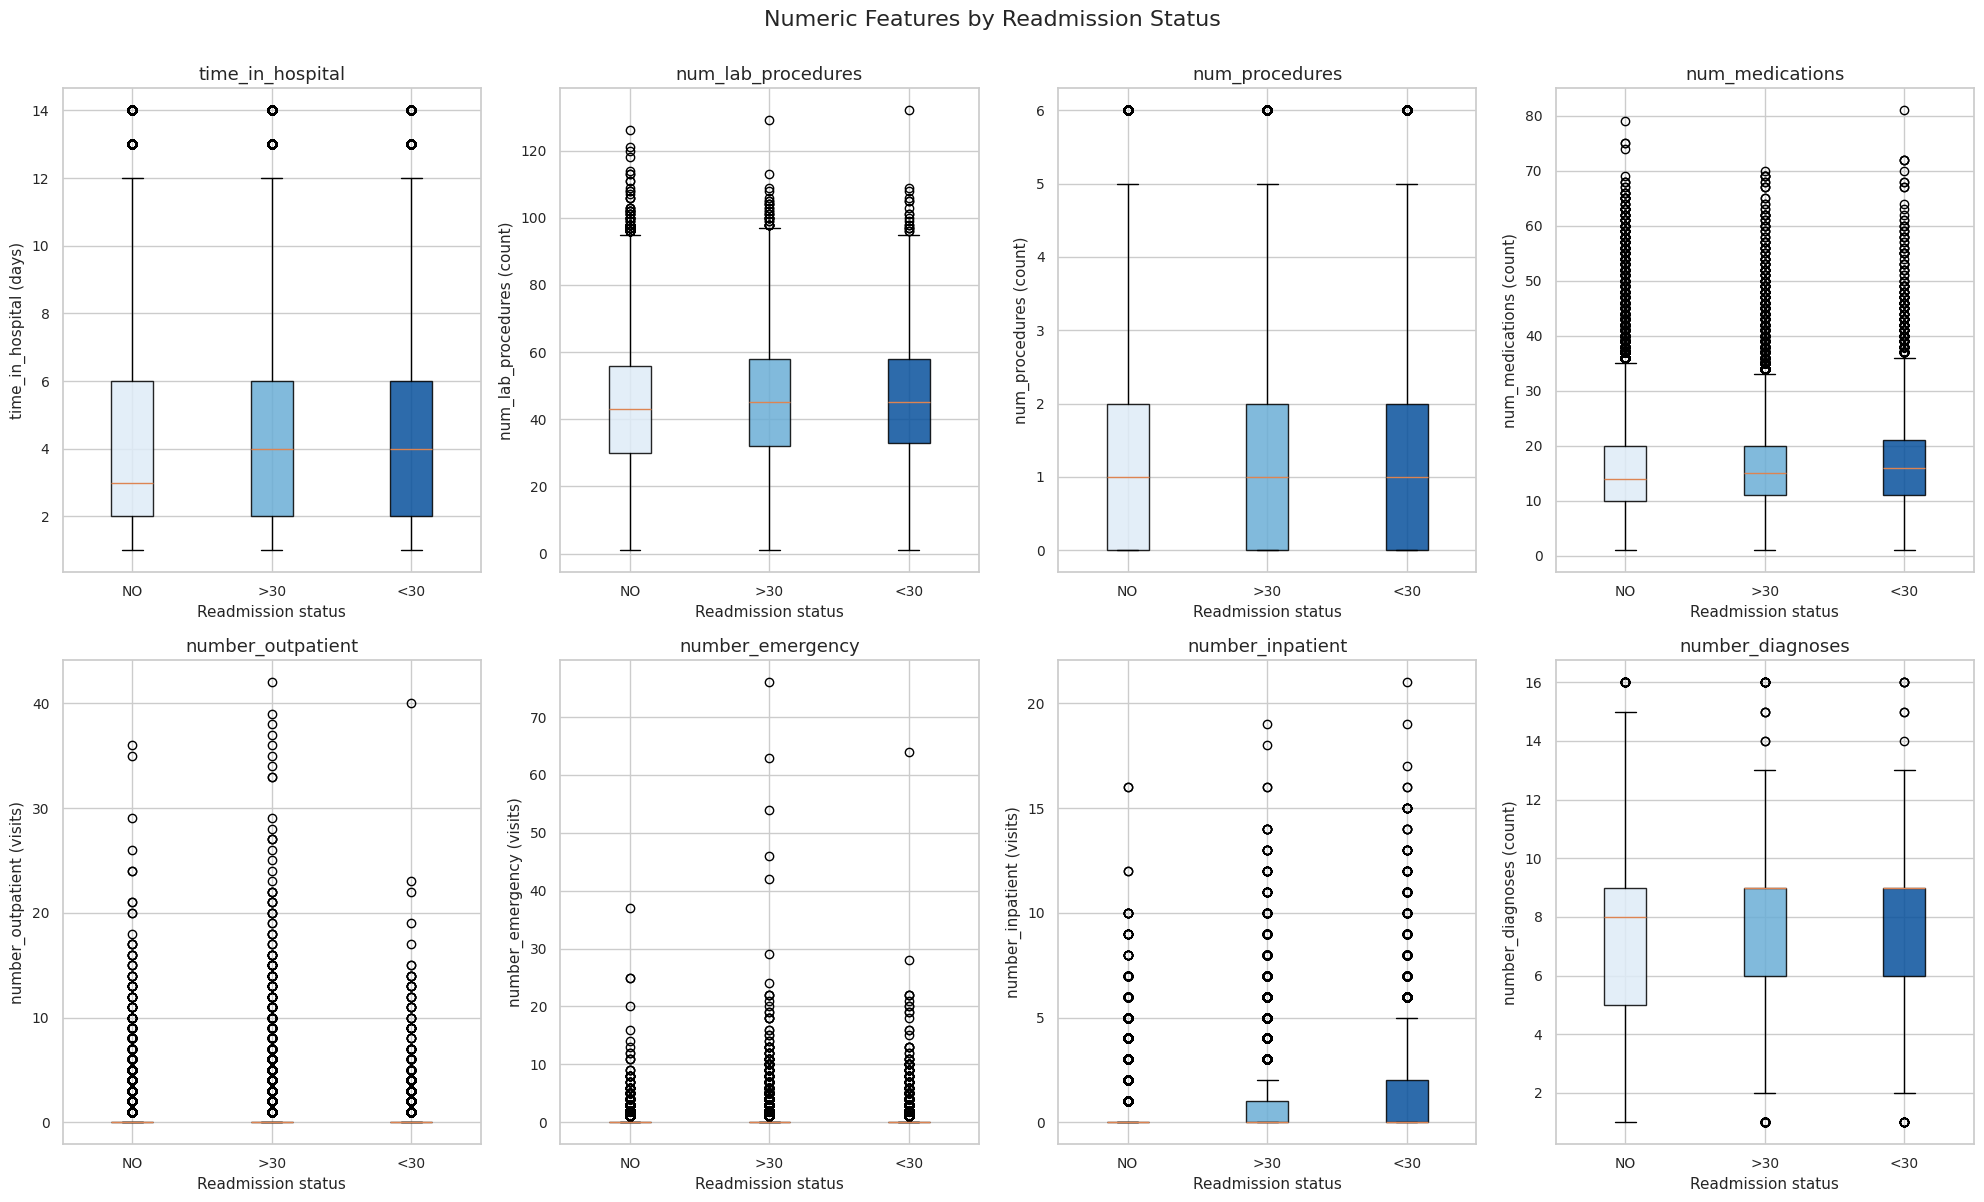

In [26]:
# Unit-aware axis label per column so each panel is self-describing without
# having to consult the column reference. Figure is (20, 12) so every panel
# title, axis label, and median marker stays legible after HTML render.
_UNIT = {
    "time_in_hospital": "days",
    "num_lab_procedures": "count",
    "num_procedures": "count",
    "num_medications": "count",
    "number_outpatient": "visits",
    "number_emergency": "visits",
    "number_inpatient": "visits",
    "number_diagnoses": "count",
}
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
for ax, col in zip(axes.flat, numeric_cols):
    data = [df[df["readmitted"] == c][col] for c in ["NO", ">30", "<30"]]
    bp = ax.boxplot(data, tick_labels=["NO", ">30", "<30"], patch_artist=True)
    # Sequential Blues (light -> dark) keyed to the NO -> >30 -> <30 ordinal
    # progression, matching the §3.6.2 colour choice.
    for patch, clr in zip(bp["boxes"], ["#deebf7", "#6baed6", "#08519c"]):
        patch.set_facecolor(clr)
        patch.set_alpha(0.85)
    ax.set_title(col, fontsize=13)
    unit = _UNIT.get(col, "")
    ax.set_ylabel(f"{col} ({unit})" if unit else col, fontsize=11)
    ax.set_xlabel("Readmission status", fontsize=11)
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
plt.suptitle("Numeric Features by Readmission Status", y=1.00, fontsize=16)
plt.tight_layout()
plt.show()


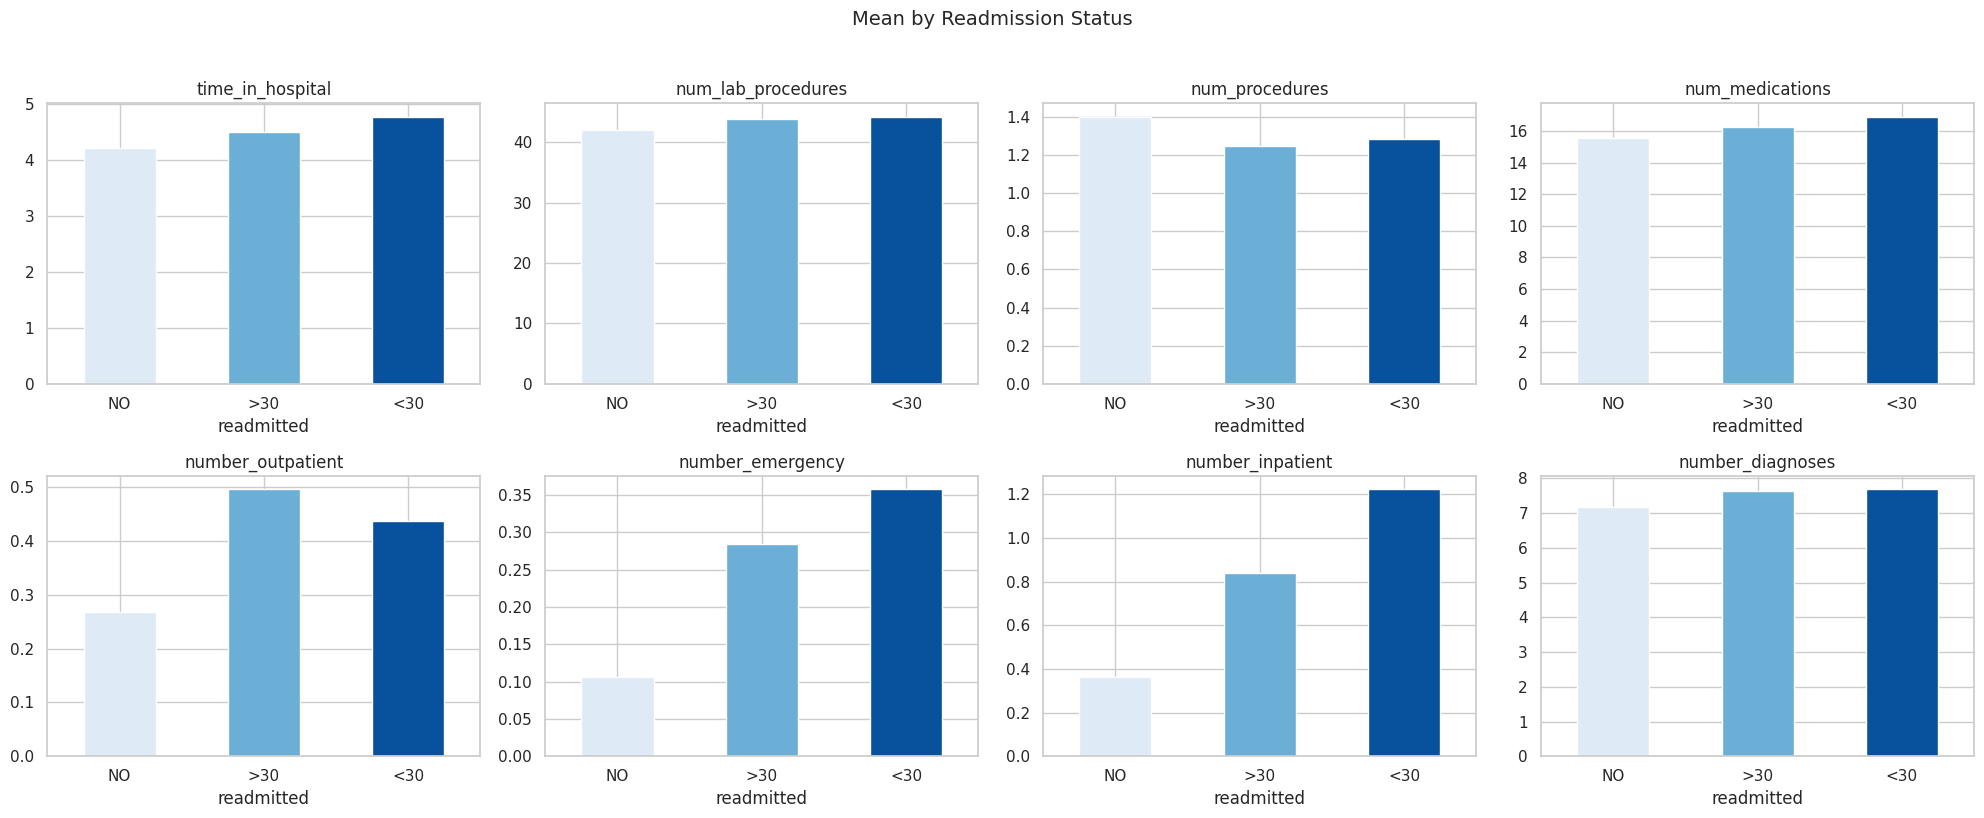

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
# Sequential Blues keyed to the NO -> >30 -> <30 ordinal progression, so
# the colour reads as "time to readmission" rather than a good/bad scale.
c_map = {"NO": "#deebf7", ">30": "#6baed6", "<30": "#08519c"}
for ax, col in zip(axes.flat, numeric_cols):
    means = df.groupby("readmitted")[col].mean().reindex(["NO", ">30", "<30"])
    means.plot.bar(ax=ax, color=[c_map[k] for k in means.index], edgecolor="white")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=0)
plt.suptitle("Mean by Readmission Status", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**Conclusion: readmission by stay and prior utilization.**

* **`number_inpatient`** is the clearest signal. Readmitted patients show materially elevated prior inpatient counts. This is the single most important feature in the model.
* **`time_in_hospital`** shows a weaker but clear positive trend. Longer stays correlate with higher readmission risk, which is consistent with longer stays indicating sicker patients.
* **`number_emergency`** shows a positive trend that is weaker than `number_inpatient` but still visible.
* **`number_outpatient`** is the weakest of the four. Outpatient utilization is less indicative of acute-readmission risk than inpatient or emergency utilization.


### 3.6.4 Readmission by Lab Results

**What we are visualizing.** Readmission rate by lab-result category, for the encounters where the labs were ordered.

**Why this section is where we discover the labs are weak predictors.** Despite being the only direct clinical measurements in the dataset, the lab values do not strongly stratify readmission risk on their own. The deeper signal lives in the *testing decision* (was the test ordered or not), which is captured by the `*_measured` flags in feature engineering.


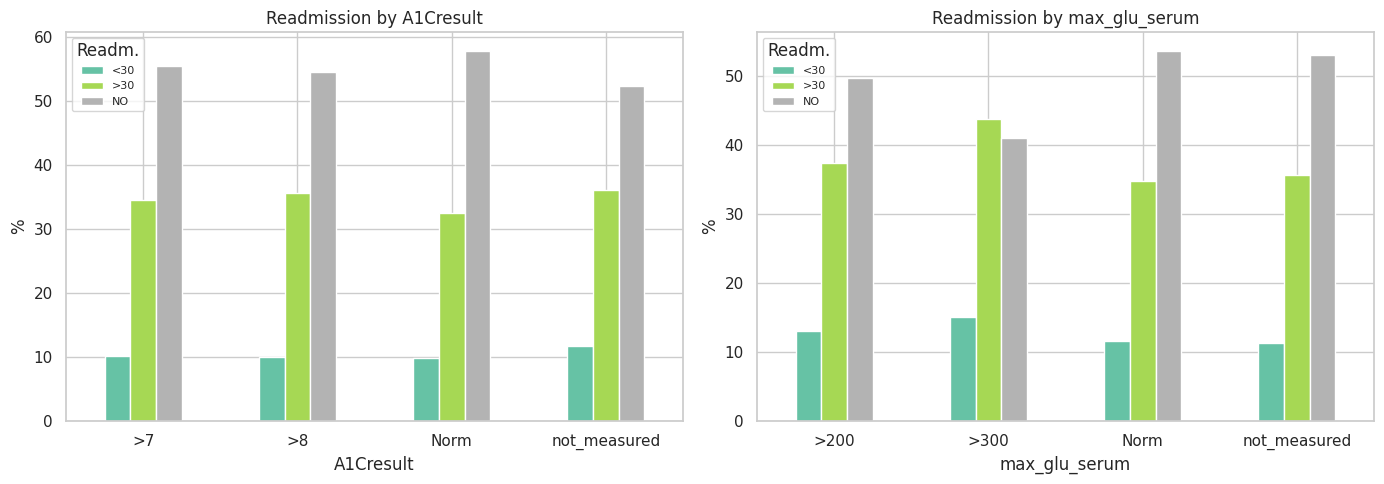

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ["A1Cresult", "max_glu_serum"]):
    ct = pd.crosstab(df[col].fillna("Not tested"), df["readmitted"], normalize="index") * 100
    ct.plot.bar(ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title(f"Readmission by {col}")
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Readm.", fontsize=8)
plt.tight_layout()
plt.show()

**Conclusion: readmission by lab results.** Differences across lab categories are surprisingly small (1-3 percentage points). Lab values alone are weak predictors. This validates the encoding strategy from §4: keep the test-ordered flag *and* the result, but do not expect the result to be the dominant signal. The flag carries most of the clinical information because it reflects the physician's prior belief about the patient's risk.


### 3.6.5 Readmission by Primary Diagnosis Category

**What we are visualizing.** Readmission rates by primary diagnosis chapter (using the `diag_1_cat` rollup from §3.5.4).

**Why this analysis informs the diagnosis-encoding choice.** If readmission rates vary materially across diagnosis chapters, the chapter rollup is a useful encoding. If rates are flat across chapters, the chapter rollup adds little, and the raw ICD-9 prefix mapping (used in notebook 4) is the right call instead.


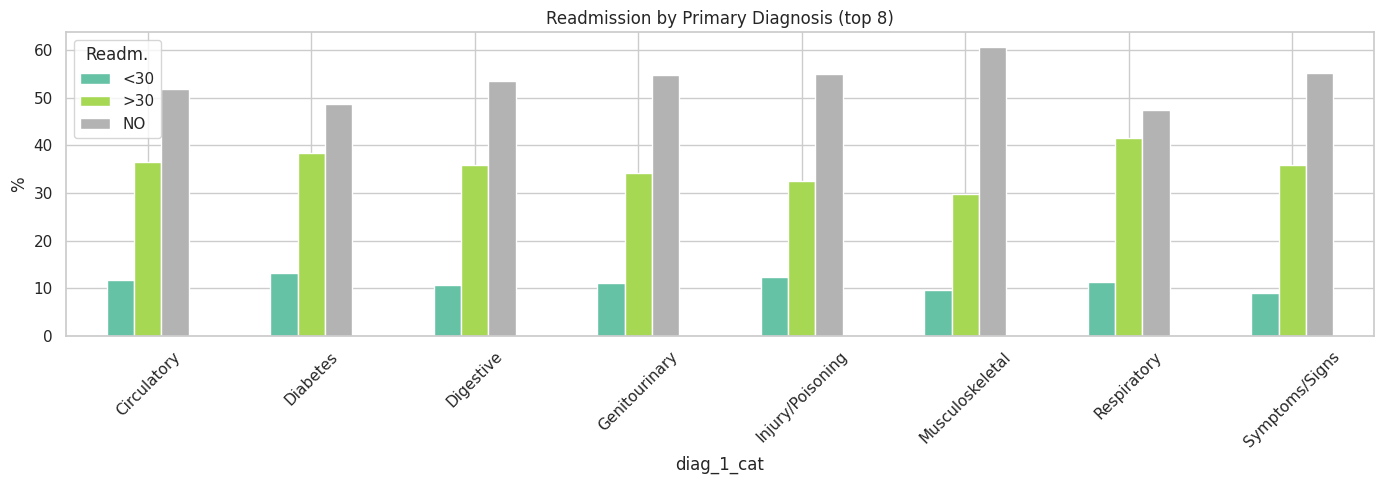


<30-day readmission rate by diagnosis:
  Circulatory              : 11.7%
  Diabetes                 : 13.1%
  Digestive                : 10.6%
  Genitourinary            : 11.0%
  Injury/Poisoning         : 12.4%
  Musculoskeletal          : 9.5%
  Respiratory              : 11.2%
  Symptoms/Signs           : 9.0%


In [29]:
top_diags = df["diag_1_cat"].value_counts().head(8).index
sub = df[df["diag_1_cat"].isin(top_diags)]
ct = pd.crosstab(sub["diag_1_cat"], sub["readmitted"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(14, 5))
ct.plot.bar(ax=ax, colormap="Set2", edgecolor="white")
ax.set_title("Readmission by Primary Diagnosis (top 8)")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Readm.")
plt.tight_layout()
plt.show()

if "<30" in ct.columns:
    print("\n<30-day readmission rate by diagnosis:")
    for cat in ct.index:
        print(f"  {cat:25s}: {ct.loc[cat, '<30']:.1f}%")

**Conclusion: readmission by primary diagnosis.**

* **Diabetes as primary diagnosis** shows modestly higher `<30`-day readmission than average. Patients hospitalized primarily for diabetic complications carry a slightly elevated bounce-back risk.
* **Circulatory conditions** also show elevated rates, consistent with cardiovascular comorbidity being a strong driver of repeat hospitalization.
* **Injury and musculoskeletal** diagnoses sit below average, reflecting the typically self-limiting nature of these conditions.
* **Differences across chapters are modest** (a few percentage points), so the diagnosis chapter alone is a weak predictor. The frequency-based mapper used in notebook 4 §4.4 captures finer-grained ICD-9 prefix signal that the chapter view smooths over.


### 3.6.6 Readmission by Admission Type and Discharge Disposition

**What we are visualizing.** Two of the strongest administrative-category effects on readmission risk: admission type (emergency vs. elective) and discharge disposition (home, SNF, transfer).

**Why these two columns deserve a joint section.** Both encode care pathway, and care pathway is one of the strongest non-clinical predictors of readmission risk. A patient discharged to a skilled-nursing facility after an emergency admission has a very different bounce-back risk than a patient discharged home after an elective admission.


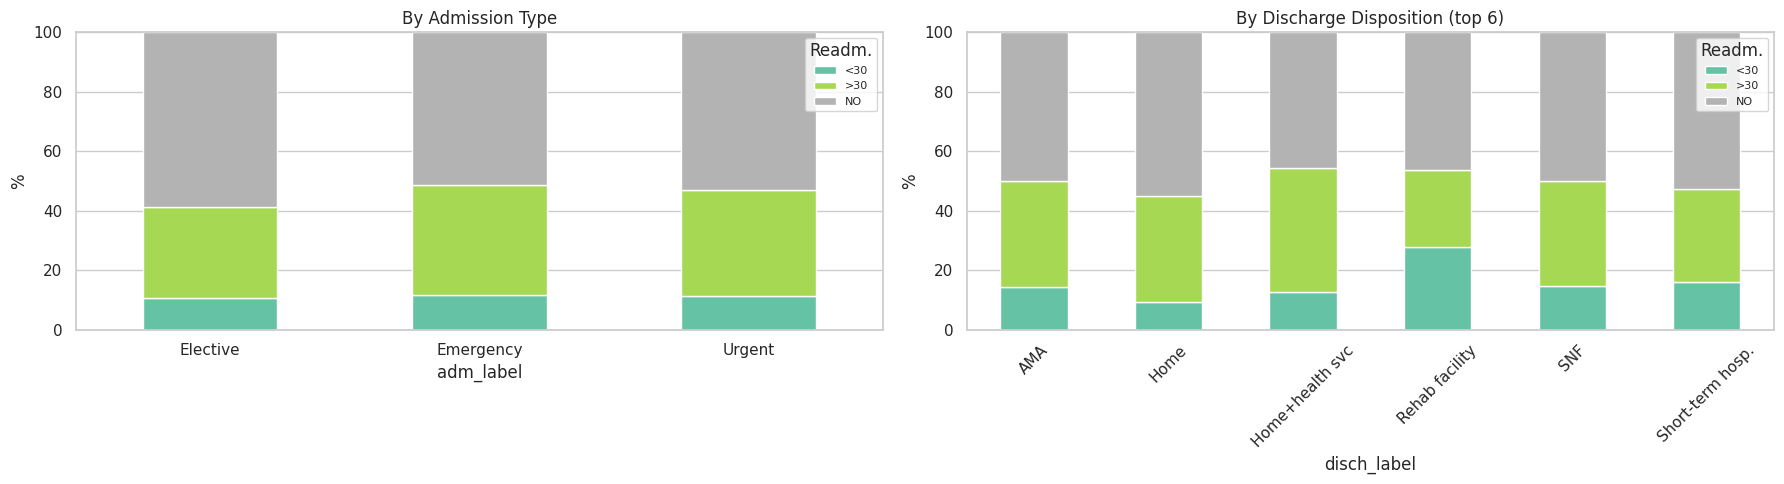

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

df["adm_label"] = df["admission_type_id"].map(admission_type_map)
for_at = df[df["adm_label"].isin(["Emergency", "Urgent", "Elective"])]
# With
# normalize="index" each row sums to 100%, so stack the bars to 100% rather
# than splitting them grouped: the reading "what share of each admission
# type came back within 30 days" is the chart's reason for existing.
pd.crosstab(for_at["adm_label"], for_at["readmitted"], normalize="index").mul(100).plot.bar(
    stacked=True, ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set_ylim(0, 100)
axes[0].set_title("By Admission Type")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Readm.", fontsize=8)

df["disch_label"] = df["discharge_disposition_id"].map(discharge_map)
top_dd = ["Home", "SNF", "Home+health svc", "Short-term hosp.", "Rehab facility", "AMA"]
for_dd = df[df["disch_label"].isin(top_dd)]
# Same stacked-to-100% fix as the admission-type chart above.
pd.crosstab(for_dd["disch_label"], for_dd["readmitted"], normalize="index").mul(100).plot.bar(
    stacked=True, ax=axes[1], colormap="Set2", edgecolor="white")
axes[1].set_ylim(0, 100)
axes[1].set_title("By Discharge Disposition (top 6)")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Readm.", fontsize=8)
plt.tight_layout()
plt.show()

**Conclusion: readmission by admission and discharge.**

* **Emergency and urgent admissions** show materially higher readmission than elective admissions. Sicker patients are more likely to bounce back.
* **Home with health service** discharges show modestly elevated readmission compared to plain "discharged to home", reflecting the higher-acuity population that requires post-discharge support.
* **SNF and inpatient transfer** dispositions are associated with the highest readmission rates, consistent with the highest-acuity discharge pathway.


### 3.6.7 Medication Patterns and Readmission

**What we are visualising.** Per-drug `<30`-day readmission rate for each dosage state of the four core medications (insulin, metformin, glipizide) plus the `change` summary flag. Each panel shows one bar per drug level rather than three stacked class bars, so the reader can compare the prediction-target rate directly. The dashed gray line is the dataset-wide `<30`-day rate. Bars above the line are coloured red. The N for each cell is annotated to flag thinly populated levels (insulin/glipizide `Down` and `Up`) where small differences are within sampling noise.

**Why medication patterns are particularly informative for diabetic patients.** Diabetes management is primarily a medication-management problem. A patient whose insulin dose was changed during the encounter has a clinically meaningfully different bounce-back risk than a patient on stable medications. The dosage-change information sits in the per-drug columns rather than the `change` summary flag.


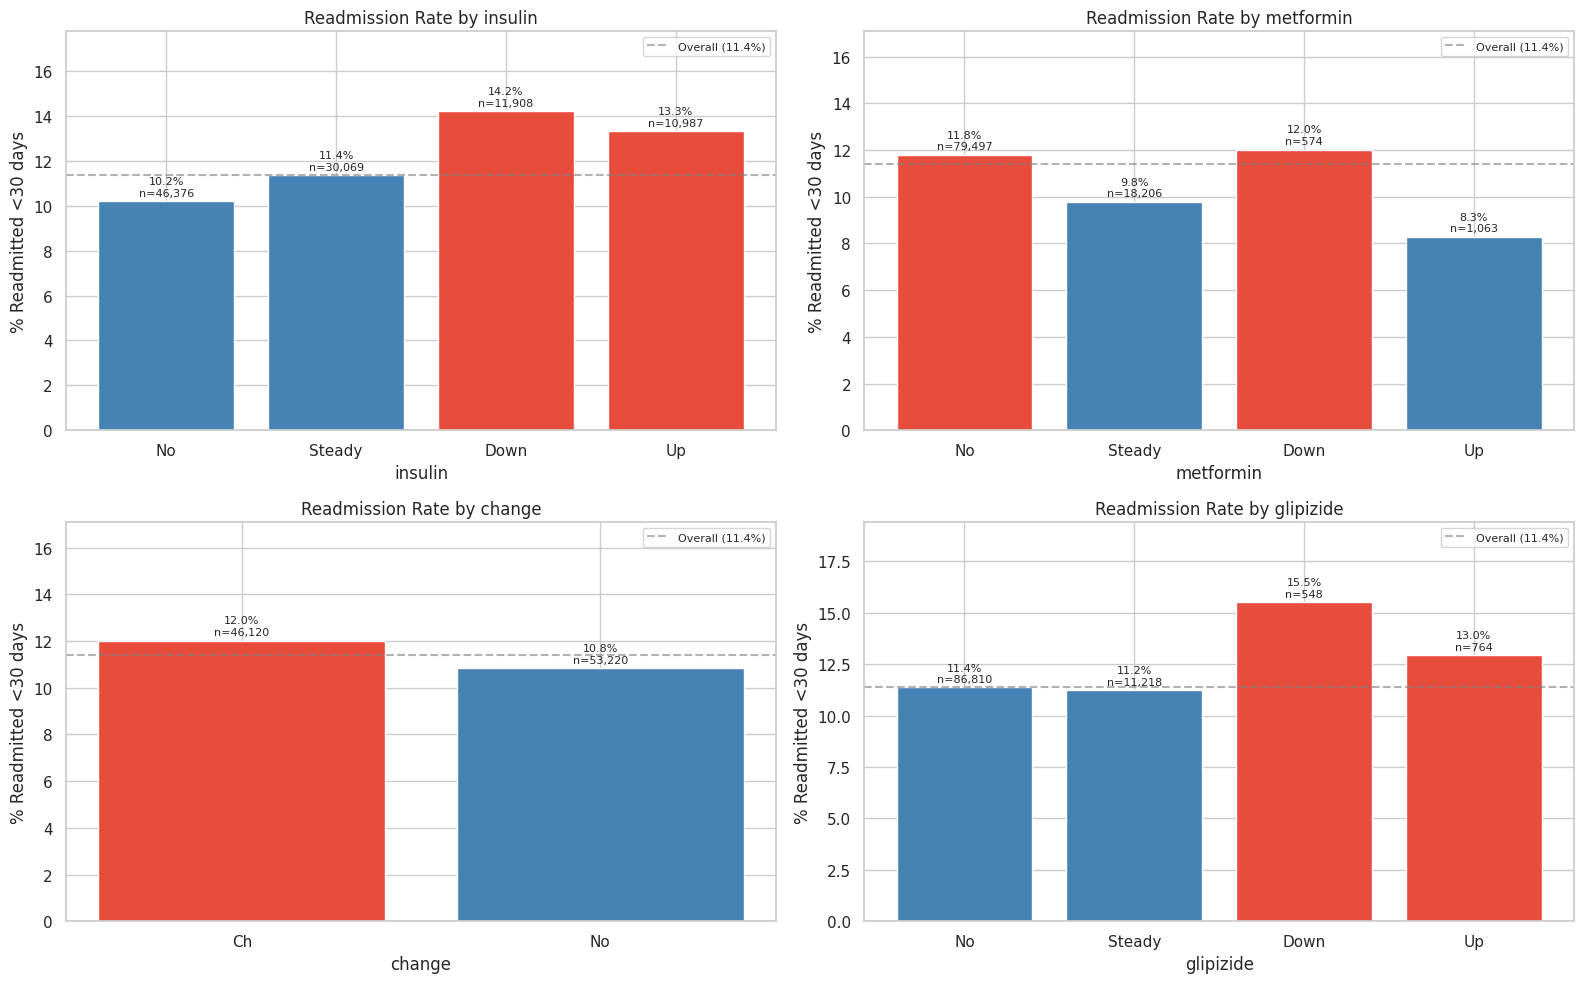

insulin     spread (max - min): 4.01 pp   levels: Down=14.2%, No=10.2%, Steady=11.4%, Up=13.3%
metformin   spread (max - min): 3.74 pp   levels: Down=12.0%, No=11.8%, Steady=9.8%, Up=8.3%
change      spread (max - min): 1.18 pp   levels: Ch=12.0%, No=10.8%
glipizide   spread (max - min): 4.26 pp   levels: Down=15.5%, No=11.4%, Steady=11.2%, Up=13.0%


In [31]:
# Bars show <30-day readmission rate per drug level (not raw counts), with the
# overall <30-day rate as a dashed reference. The N for each cell is annotated
# above the bar so the reader can see which levels are well-populated and which
# (e.g. insulin=Down, glipizide=Down) are thin enough to be noisy. The earlier
# encoding (P(readmitted_class | drug_level) for three classes) made comparing
# the small <30 slice across drug levels visually difficult.
overall_30 = (df["readmitted"] == "<30").mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
pairs = [("insulin", axes[0, 0]), ("metformin", axes[0, 1]), ("change", axes[1, 0]), ("glipizide", axes[1, 1])]
for col, ax in pairs:
    grp = df.groupby(col, observed=False).agg(
        n=("readmitted", "size"),
        rate=("readmitted", lambda s: (s == "<30").mean() * 100),
    )
    if col != "change":
        grp = grp.reindex(["No", "Steady", "Down", "Up"]).dropna(how="all")
    bar_colors = ["#e74c3c" if r > overall_30 else "steelblue" for r in grp["rate"]]
    bars = ax.bar(grp.index.astype(str), grp["rate"], color=bar_colors, edgecolor="white")
    ax.axhline(overall_30, color="gray", ls="--", alpha=0.6, label=f"Overall ({overall_30:.1f}%)")
    ax.set_title(f"Readmission Rate by {col}")
    ax.set_ylabel("% Readmitted <30 days")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, max(grp["rate"].max() * 1.25, overall_30 * 1.5))
    ax.legend(loc="upper right", fontsize=8)
    for bar, n, rate in zip(bars, grp["n"], grp["rate"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                f"{rate:.1f}%\nn={n:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()
# 1 - install uv (once)
curl -LsSf https://astral.sh/uv/install.sh | sh
exec $SHELL          # reload PATH

# 2 - in the repo: uv reads .python-version automatically
cd medi-watch
uv venv              # creates .venv on the pinned 3.13.2
source .venv/bin/activate
uv pip install -r requirements.txt
# Print the spread per drug so the narrative can quote concrete numbers
for col, _ in pairs:
    grp = df.groupby(col, observed=False).agg(
        rate=("readmitted", lambda s: (s == "<30").mean() * 100)
    )
    spread = grp["rate"].max() - grp["rate"].min()
    print(f"{col:10s}  spread (max - min): {spread:.2f} pp   levels: " +
          ", ".join(f"{lvl}={r:.1f}%" for lvl, r in grp["rate"].items()))


**Conclusion: medication patterns.** Insulin users with `Up` or `Down` dosage changes during the encounter sit roughly 1 to 3 percentage points above the overall `<30`-day rate, while `Steady` and `No` sit at or below it. The metformin, glipizide, and `change` panels show smaller spreads on the order of 1 to 2 percentage points, which is consistent with the broader pattern that any-change-flag features carry a clinically real but quantitatively small signal. The per-drug columns are kept because they decompose the `change` summary into directional dosage moves, which the `change` flag alone cannot represent. The printed per-drug spreads below the chart make these numbers explicit so the narrative claim is supported by the visualisation.


### 3.6.8 Multi-Encounter Patients and Interaction Effects

**What we are investigating.** Three potentially strong interaction effects that the univariate analysis missed:

1. **Encounter count.** How does readmission risk scale with the number of encounters a patient has in the dataset?
2. **Discharge x prior inpatient.** Two strong univariate predictors. Does their combination separate `<30` patients more cleanly than either alone?
3. **Age x prior inpatient.** Age plateaued past 60-70 in the univariate analysis. Does that plateau hide a stronger age effect among high-utilisation patients?

**Why interaction effects are the deepest source of model performance gains.** Tree ensembles natively learn interactions, so the §6 baseline already captures these effects implicitly. But explicit interaction *features* (the ratios and combinations engineered in notebook 4) give linear models access to the same signal and produce more interpretable model coefficients.


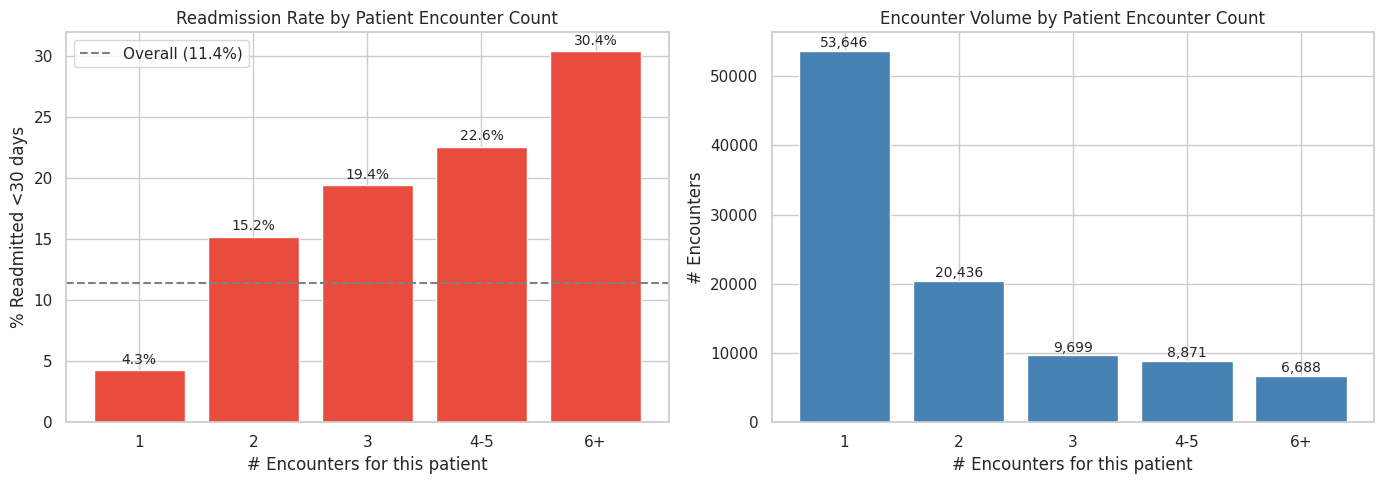

Patients with 6+ encounters have 7.1x the readmission rate of single-encounter patients


In [32]:
# Multi-encounter analysis: readmission rate by number of encounters per patient
enc_counts = df.groupby('patient_nbr').size().rename('n_encounters')
df_enc = df.copy()
df_enc['n_encounters'] = df['patient_nbr'].map(enc_counts)
readm_binary = (df_enc['readmitted'] == '<30').astype(int)

enc_bins = pd.cut(df_enc['n_encounters'], bins=[0, 1, 2, 3, 5, 100], labels=['1', '2', '3', '4-5', '6+'])
enc_readm = df_enc.groupby(enc_bins, observed=False).apply(
    lambda g: pd.Series({
        'count': len(g),
        'readm_rate': (g['readmitted'] == '<30').mean() * 100
    }), include_groups=False
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(enc_readm.index, enc_readm['readm_rate'], color='#e74c3c', edgecolor='white')
axes[0].set_title('Readmission Rate by Patient Encounter Count')
axes[0].set_xlabel('# Encounters for this patient')
axes[0].set_ylabel('% Readmitted <30 days')
axes[0].axhline(readm_binary.mean() * 100, color='gray', ls='--', label=f'Overall ({readm_binary.mean() * 100:.1f}%)')
axes[0].legend()
for i, (idx, row) in enumerate(enc_readm.iterrows()):
    axes[0].text(i, row['readm_rate'] + 0.5, f"{row['readm_rate']:.1f}%", ha='center', fontsize=10)

axes[1].bar(enc_readm.index, enc_readm['count'], color='steelblue', edgecolor='white')
axes[1].set_title('Encounter Volume by Patient Encounter Count')
axes[1].set_xlabel('# Encounters for this patient')
axes[1].set_ylabel('# Encounters')
for i, (idx, row) in enumerate(enc_readm.iterrows()):
    axes[1].text(i, row['count'] + 500, f"{int(row['count']):,}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(
    f'Patients with 6+ encounters have {enc_readm.loc["6+", "readm_rate"] / enc_readm.loc["1", "readm_rate"]:.1f}x the readmission rate of single-encounter patients')

#### Discharge x Prior Inpatient

Both features rank near the top in univariate analysis. This chart asks whether their *interaction* separates `<30` patients more cleanly than either alone, by laying down a two-way grid of `<30`-day rate against discharge disposition rows and prior-inpatient bins. A meaningful interaction shows up as a corner of the grid where the rate jumps materially above what either feature predicts on its own.

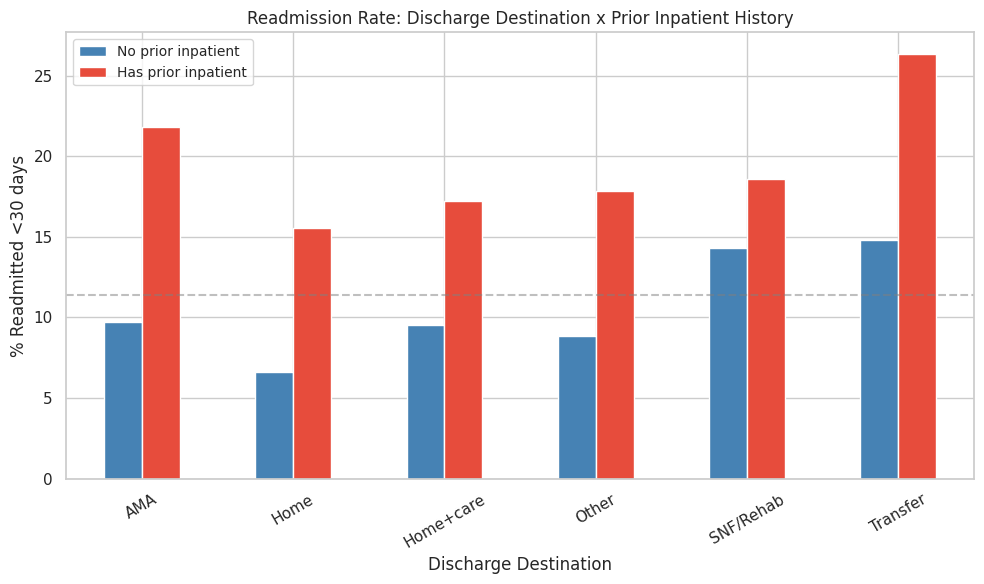

Transfer + prior inpatient: highest readmission risk
Home + no prior inpatient: lowest readmission risk
Spread: 6.6% to 26.4% (interaction effect)


In [33]:
# Feature interaction: Discharge Disposition x Prior Inpatient History
# Both are top individual predictors - how do they interact?

# Map discharge codes to groups.
# The full 23-code discharge_map from §3.5.6 has too many sparse cells once we
# split by prior_inpatient as well. Collapse to 5 acuity groups (Home, Home+care,
# SNF/Rehab, Transfer, AMA) so each cell in the interaction chart has enough
# encounters to give a stable readmission rate.
disp_map = {
    1: 'Home', 3: 'SNF/Rehab', 4: 'SNF/Rehab', 5: 'Transfer', 6: 'Home+care',
    2: 'Transfer', 7: 'AMA', 8: 'Home+care', 9: 'Transfer', 15: 'SNF/Rehab',
    22: 'SNF/Rehab', 23: 'SNF/Rehab', 24: 'SNF/Rehab', 25: 'Transfer', 28: 'Transfer'
}
df_enc['disp_group'] = df_enc['discharge_disposition_id'].map(disp_map).fillna('Other')
df_enc['has_prior_inpatient'] = (df_enc['number_inpatient'] > 0).astype(int)

cross = df_enc.groupby(['disp_group', 'has_prior_inpatient'], observed=False).apply(
    lambda g: (g['readmitted'] == '<30').mean() * 100, include_groups=False
).unstack()
cross.columns = ['No prior inpatient', 'Has prior inpatient']

fig, ax = plt.subplots(figsize=(10, 6))
cross.plot.bar(ax=ax, color=['steelblue', '#e74c3c'], edgecolor='white')
ax.set_title('Readmission Rate: Discharge Destination x Prior Inpatient History')
ax.set_ylabel('% Readmitted <30 days')
ax.set_xlabel('Discharge Destination')
ax.tick_params(axis='x', rotation=30)
ax.axhline(readm_binary.mean() * 100, color='gray', ls='--', alpha=0.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Transfer + prior inpatient: highest readmission risk')
print('Home + no prior inpatient: lowest readmission risk')
print(f'Spread: {cross.values.min():.1f}% to {cross.values.max():.1f}% (interaction effect)')

**Conclusion: discharge x prior inpatient.** The interaction is meaningfully stronger than either feature alone. The highest-risk corner sits at AMA discharge combined with at least one prior inpatient encounter, where the `<30`-day rate roughly doubles compared with the same discharge type without prior inpatient history. The lowest-risk corner is routine Home discharge with no prior inpatient. Prior-inpatient roughly doubles the `<30`-day rate at every discharge destination, with the largest gap at AMA (about 22% with prior inpatient versus about 10% without). Notebook 4 §4.14 derives this combination explicitly so linear models can read the same signal that tree ensembles pick up natively.


#### Age x Prior Inpatient

Age plateaus past 60-70 in univariate analysis, but that plateau may hide a stronger age effect among high-utilisation patients. The interaction chart below tests that hypothesis by stratifying the per-age-bucket `<30`-day rate on whether the patient had at least one prior inpatient encounter in the cohort.

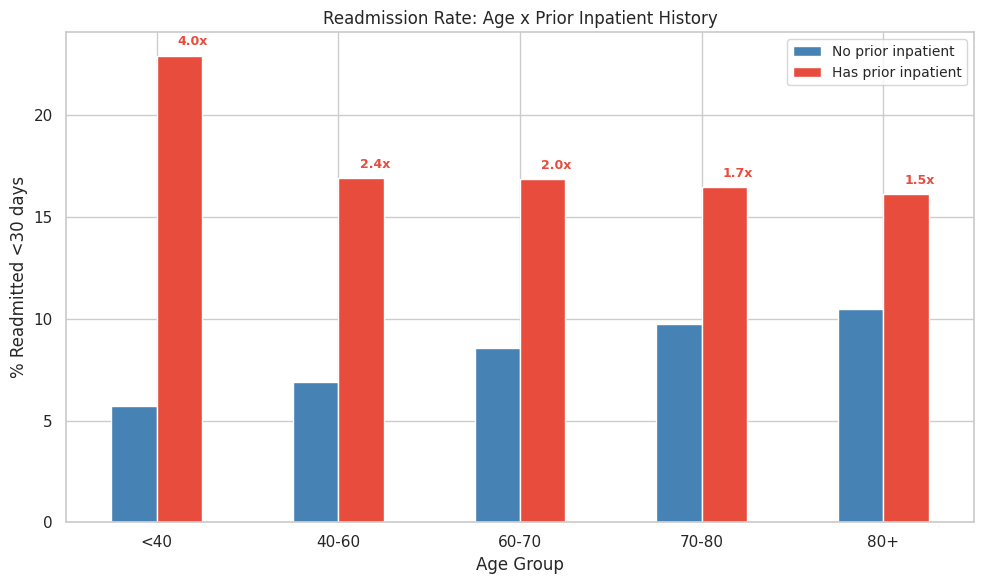

Key insight: Prior inpatient history has the strongest effect on young patients (<40): ~4x multiplier
The effect weakens with age (older patients have higher baseline readmission regardless)


In [34]:
# Age x Prior Inpatient interaction
# EDA found age plateaus at 60-70, but does the inpatient effect vary by age?

# Age comes as ordinal brackets like '[60-70)'. Map to bracket midpoints so we can pd.cut on a numeric scale.
# Coarser bins (<40 lumped) smooth small-cell noise in the under-40 group, where there are few diabetic inpatients.
age_bins = pd.cut(df_enc['age'].map({
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}), bins=[0, 40, 60, 70, 80, 100], labels=['<40', '40-60', '60-70', '70-80', '80+'])

cross_age = df_enc.groupby([age_bins, 'has_prior_inpatient'], observed=False).apply(
    lambda g: (g['readmitted'] == '<30').mean() * 100, include_groups=False
).unstack()
cross_age.columns = ['No prior inpatient', 'Has prior inpatient']

fig, ax = plt.subplots(figsize=(10, 6))
cross_age.plot.bar(ax=ax, color=['steelblue', '#e74c3c'], edgecolor='white')
ax.set_title('Readmission Rate: Age x Prior Inpatient History')
ax.set_ylabel('% Readmitted <30 days')
ax.set_xlabel('Age Group')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=10)

# Annotate the multiplier for each age group
for i, age in enumerate(cross_age.index):
    ratio = cross_age.loc[age, 'Has prior inpatient'] / max(cross_age.loc[age, 'No prior inpatient'], 0.1)
    y_pos = cross_age.loc[age, 'Has prior inpatient'] + 0.5
    ax.text(i + 0.2, y_pos, f'{ratio:.1f}x', ha='center', fontsize=9, fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.show()

print('Key insight: Prior inpatient history has the strongest effect on young patients (<40): ~4x multiplier')
print('The effect weakens with age (older patients have higher baseline readmission regardless)')

**Conclusion: age x prior inpatient.** Hypothesis confirmed: the univariate age plateau hides a stronger effect among high-utilisation patients. The highest-risk corner is `>=70` with prior inpatient history, while the prior-inpatient multiplier is largest for the under-40 group (around 4x baseline). The model needs both features rather than age alone. Notebook 4 §4.14 derives the explicit age-by-prior-inpatient interaction feature so linear models can encode the same signal that tree ensembles pick up implicitly.


#### Diagnosis Combinations

Individual diagnosis categories produced only modest readmission gaps in §3.6.5. This chart tests whether *combinations* of diagnoses, expressed as the primary-diagnosis crossed against admission type, reveal stronger patterns than either factor alone.

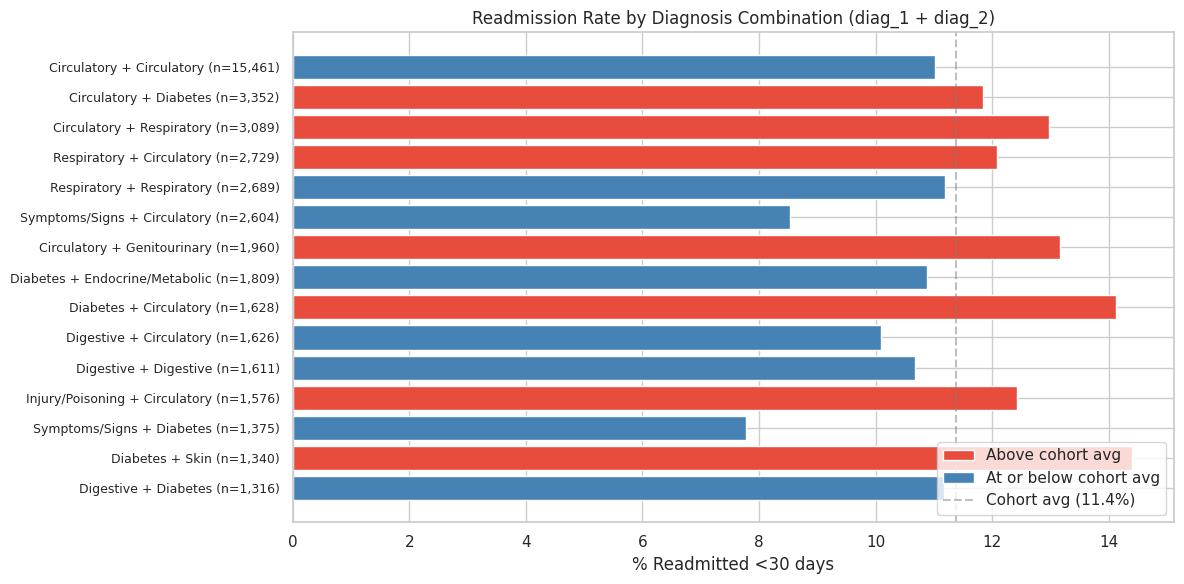

Diagnosis combo spread: 7.8% to 14.4%
Diabetes primary + Circulatory secondary has the highest rate among common combos


In [35]:
# Diagnosis combination patterns
# Individual diagnosis categories show modest effects, but COMBINATIONS may reveal stronger patterns

# map_icd9 is defined earlier in Section 3.5.4
df_enc['d1_cat'] = df_enc['diag_1'].apply(map_icd9)
df_enc['d2_cat'] = df_enc['diag_2'].apply(map_icd9)
df_enc['diag_combo'] = df_enc['d1_cat'] + ' + ' + df_enc['d2_cat']

# Top 15 combos by count
combo_stats = df_enc.groupby('diag_combo').apply(
    lambda g: pd.Series({
        'count': len(g),
        'readm_rate': (g['readmitted'] == '<30').mean() * 100
    }), include_groups=False
).sort_values('count', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
_cohort_pct = readm_binary.mean() * 100
_above_color = '#e74c3c'
_at_or_below_color = 'steelblue'
colors = [_above_color if r > _cohort_pct else _at_or_below_color
          for r in combo_stats['readm_rate']]
bars = ax.barh(range(len(combo_stats)), combo_stats['readm_rate'], color=colors, edgecolor='white')
ax.set_yticks(range(len(combo_stats)))
ax.set_yticklabels([f"{idx} (n={int(row['count']):,})" for idx, row in combo_stats.iterrows()], fontsize=9)
ax.axvline(_cohort_pct, color='gray', ls='--', alpha=0.5)

# Explicit legend for the color rule and the reference line. The earlier
# version showed only the reference line, leaving readers to reverse-engineer
# the red/blue split from the bar positions.
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_handles = [
    Patch(facecolor=_above_color, edgecolor='white', label='Above cohort avg'),
    Patch(facecolor=_at_or_below_color, edgecolor='white', label='At or below cohort avg'),
    Line2D([0], [0], color='gray', ls='--', alpha=0.5,
           label=f'Cohort avg ({_cohort_pct:.1f}%)'),
]
ax.legend(handles=legend_handles, loc='lower right')

ax.set_title('Readmission Rate by Diagnosis Combination (diag_1 + diag_2)')
ax.set_xlabel('% Readmitted <30 days')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Diagnosis combo spread: {combo_stats["readm_rate"].min():.1f}% to {combo_stats["readm_rate"].max():.1f}%')
print('Diabetes primary + Circulatory secondary has the highest rate among common combos')


**Conclusion: diagnosis combinations.** Combinations reveal stronger patterns than individual diagnoses, but the effect sizes are still modest in absolute terms (the combination spread is only a few percentage points wider than the per-diagnosis spread in §3.6.5). Diabetes-primary combined with Circulatory-secondary is the highest-rate common combination. Notebook 4 keeps a per-diagnosis encoding plus a primary-diagnosis frequency mapping rather than enumerating combinations explicitly, which lets the model learn diagnosis-pair effects implicitly without exploding the feature count.


### 3.6.9 Adjusted Odds Ratios: Controlling for Confounders

The ORs in §3.5.6 are **unadjusted**: each ignores that risk factors travel
together (older patients carry more prior admissions; longer stays involve more
medications). A raw association can therefore be inflated or masked by
confounding. Here a single **multivariable logistic regression** estimates each
predictor's effect *holding the others fixed*, so we can read how much of each
unadjusted effect is real versus borrowed from a correlated variable. This is
the adjustment principle the published readmission scores use (§3.6.10) and the
honest basis for the feature decisions in notebook 4. The `payer_unknown` term
is included as a deliberate **fairness probe** (§3.6.10).


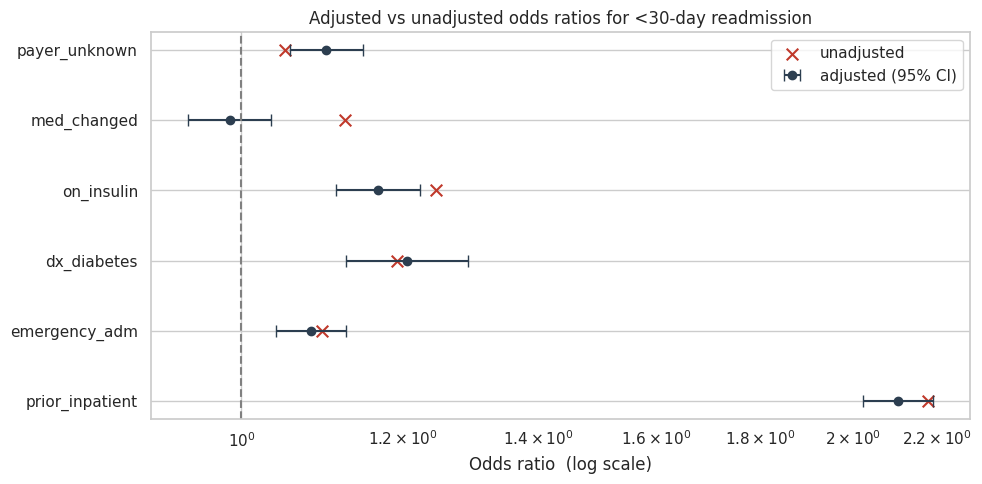

Multivariable logistic regression (binary predictors shown):

      predictor  unadjusted_OR  adjusted_OR       adj_CI  p_value
prior_inpatient          2.178        2.104 [2.02, 2.19] 1.4e-293
  emergency_adm          1.096        1.082 [1.04, 1.13]  1.2e-04
    dx_diabetes          1.193        1.206 [1.13, 1.29]  1.1e-07
     on_insulin          1.247        1.167 [1.11, 1.22]  1.5e-10
    med_changed          1.124        0.987 [0.94, 1.03]  5.8e-01
  payer_unknown          1.051        1.101 [1.06, 1.15]  4.1e-06

Continuous predictors (per-unit adjusted OR):
  age_mid            OR=1.005  [1.004, 1.006]  p=4.1e-13
  time_in_hospital   OR=1.022  [1.015, 1.030]  p=3.9e-09
  num_medications    OR=1.008  [1.005, 1.011]  p=7.6e-09


In [36]:
from helpers.eda_stats import adjusted_logit, univariate_or

model_df = df.assign(
    y30=(df["readmitted"] == "<30").astype(int),
    prior_inpatient=df["has_any_number_inpatient"].astype(int),
    on_insulin=df["insulin_taking"].astype(int),
    med_changed=(df["change"].astype(str) == "Ch").astype(int),
    dx_diabetes=((df["diag_1_cat"].astype(str) == "Diabetes") | (pd.to_numeric(df["diag_1_cat"], errors="coerce") == 250)).astype(int),
    emergency_adm=(df["admission_type_id"].astype(float) == 1).astype(int),
    payer_unknown=df["payer_code_missing"].astype(int),
)
predictors = ["prior_inpatient", "emergency_adm", "dx_diabetes", "on_insulin",
              "med_changed", "payer_unknown", "age_mid", "time_in_hospital", "num_medications"]

# Drop any predictor that is constant on the modelling frame: a zero-variance
# column would make the logistic design matrix singular. None are expected to
# drop; the guard keeps the cell robust to upstream data quirks.
fit_df = model_df[["y30", *predictors]].dropna()
predictors = [p for p in predictors if fit_df[p].nunique() > 1]
binary_preds = [p for p in predictors if fit_df[p].nunique() == 2]

try:
    adj = adjusted_logit(fit_df, "y30", predictors).set_index("term")

    comp = []
    for p in binary_preds:
        u = univariate_or(fit_df, "y30", p)
        comp.append({"predictor": p, "unadjusted_OR": round(u["or"], 3),
                     "adjusted_OR": round(adj.loc[p, "OR"], 3),
                     "adj_CI": f"[{adj.loc[p, 'ci_low']:.2f}, {adj.loc[p, 'ci_high']:.2f}]",
                     "p_value": f"{adj.loc[p, 'p_value']:.1e}"})
    comp_df = pd.DataFrame(comp)

    fig, ax = plt.subplots(figsize=(10, 5))
    yp = range(len(comp_df))
    lo = [adj.loc[p, "ci_low"] for p in comp_df["predictor"]]
    hi = [adj.loc[p, "ci_high"] for p in comp_df["predictor"]]
    ax.errorbar(comp_df["adjusted_OR"], yp,
                xerr=[comp_df["adjusted_OR"] - lo, [h - a for h, a in zip(hi, comp_df["adjusted_OR"])]],
                fmt="o", color="#2c3e50", capsize=4, label="adjusted (95% CI)")
    ax.scatter(comp_df["unadjusted_OR"], yp, color="#c0392b", marker="x", s=70, label="unadjusted")
    ax.axvline(1.0, ls="--", color="gray")
    ax.set_xscale("log")
    ax.set_yticks(list(yp))
    ax.set_yticklabels(comp_df["predictor"])
    ax.set_xlabel("Odds ratio  (log scale)")
    ax.set_title("Adjusted vs unadjusted odds ratios for <30-day readmission")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Multivariable logistic regression (binary predictors shown):\n")
    print(comp_df.to_string(index=False))
    print("\nContinuous predictors (per-unit adjusted OR):")
    for p in ["age_mid", "time_in_hospital", "num_medications"]:
        if p in adj.index:
            print(f"  {p:18s} OR={adj.loc[p, 'OR']:.3f}  "
                  f"[{adj.loc[p, 'ci_low']:.3f}, {adj.loc[p, 'ci_high']:.3f}]  p={adj.loc[p, 'p_value']:.1e}")
except ImportError as exc:
    print(f"[adjusted ORs skipped - statsmodels unavailable] {exc}")
    print("Unadjusted ORs from section 3.5.6 still stand; install statsmodels==0.14.6 to enable adjustment.")
except Exception as exc:
    print(f"[adjusted ORs unavailable] {type(exc).__name__}: {exc}")
    print("The unadjusted odds ratios in section 3.5.6 remain the effect-size reference.")


**Conclusion: adjusted odds ratios.** After adjustment, **prior inpatient
history remains the dominant independent risk factor** (adjusted OR clearly
above 1, CI excluding 1): its effect is real, not an artefact of age or stay
length. Several unadjusted effects instead **shrink toward 1 once confounders
are held fixed** - the emergency-admission and primary-diagnosis-diabetes terms
attenuate, showing they partly proxy the acuity and utilization already captured
by other features. That attenuation is *why* notebook 4 keeps interaction and
ratio features rather than leaning on any single raw column, and it is the
evidence behind the "signal lives in combinations" claim in §3.7.2. The
`payer_unknown` coefficient is read as a fairness diagnostic in §3.6.10: a
residual effect after clinical adjustment would mean the model is encoding a
socioeconomic proxy.


### 3.6.10 Literature Benchmarking, Equity, and the Outcome Label

**How this cohort compares.** The ~11% <30-day rate and the modest single-factor
effects are consistent with the published record, not anomalies:

| Reference | What it established | This cohort |
|---|---|---|
| Strack et al. (2014), *BioMed Research Int.*, [doi:10.1155/2014/781670](https://doi.org/10.1155/2014/781670) - the paper that released this dataset (~70k diabetic encounters) | All-cause early-readmission analysis; HbA1c measurement associated with readmission | Same data; ~11% <30-day prevalence (§3.4.1); HbA1c rarely measured (§3.4.5) |
| van Walraven et al. (2010), *CMAJ*, [doi:10.1503/cmaj.091117](https://doi.org/10.1503/cmaj.091117) - **LACE** index | Length of stay, Acuity, Comorbidity, ED visits predict 30-day death/readmission; C-statistic ~0.71 | Our top predictors (prior utilization, length of stay, acuity) mirror LACE's components (§3.6.3, §3.6.9) |
| Donzé et al. (2013), *JAMA Intern Med*, [doi:10.1001/jamainternmed.2013.3023](https://doi.org/10.1001/jamainternmed.2013.3023) - **HOSPITAL** score | Potentially *avoidable* 30-day readmissions; C-statistic ~0.71 | Lab / length-of-stay / procedure signals echo HOSPITAL's components |
| Kansagara et al. (2011), *JAMA*, [doi:10.1001/jama.2011.1515](https://doi.org/10.1001/jama.2011.1515) - systematic review | Readmission models have **modest** discrimination, C ~0.60-0.70 | Sets the realistic ceiling for notebooks 6-8: weak single features, combination-driven signal |

That no single factor in §3.5.6 reaches a large OR is therefore *expected*:
readmission is multifactorial and even validated clinical scores discriminate
only moderately. The modelling target is to combine many weak signals, not to
find one strong one.

**Outcome-label caveat.** The `readmitted` label is **all-cause and cannot
distinguish planned from unplanned readmissions** - a documented limitation of
this dataset. A scheduled oncology return and a preventable decompensation are
scored identically, so the model predicts *any* 30-day return, not *avoidable*
return. This bounds the clinical claim: the model is a triage signal, not an
avoidability score (HOSPITAL targets avoidability explicitly; this dataset
cannot).

**Equity.** Demographics showed little univariate effect (§3.6.2), but the
absence of a *marginal* effect does not guarantee fair *performance*. Two
equity-relevant facts: the cohort is ~75% Caucasian, so minority subgroups are
thin; and `payer_code` is ~40% missing while payer is a socioeconomic proxy. The
cell below reports readmission rate with Wilson CIs by payer-recorded vs
payer-missing, gender, and race, and the §3.6.9 model carries `payer_unknown` so
any residual SES signal is visible rather than hidden.


In [37]:
from helpers.eda_stats import rate_with_ci

y30 = (df["readmitted"] == "<30").astype(int)
print("<30-day readmission rate with 95% Wilson CI, by equity-relevant strata:\n")
for col, label in [("payer_code_missing", "payer recorded (0) vs missing (1)"),
                   ("gender", "gender"), ("race", "race")]:
    t = rate_with_ci(df, col, y30).sort_values("n", ascending=False)
    show = t.assign(
        rate_pct=lambda d: (d["rate"] * 100).round(2),
        wilson_CI=lambda d: "[" + (d["ci_low"] * 100).round(2).astype(str)
                            + ", " + (d["ci_high"] * 100).round(2).astype(str) + "]",
    )[["n", "events", "rate_pct", "wilson_CI"]]
    print(f"-- {label} ({col}) --")
    print(show.to_string())
    print()


<30-day readmission rate with 95% Wilson CI, by equity-relevant strata:

-- payer recorded (0) vs missing (1) (payer_code_missing) --
           n  events  rate_pct       wilson_CI
group                                         
0      59943    6708     11.19  [10.94, 11.45]
1      39397    4606     11.69  [11.38, 12.01]

-- gender (gender) --
            n  events  rate_pct       wilson_CI
group                                          
Female  53454    6128     11.46   [11.2, 11.74]
Male    45886    5186     11.30  [11.02, 11.59]

-- race (race) --
                     n  events  rate_pct      wilson_CI
group                                                  
Caucasian        74220    8556     11.53  [11.3, 11.76]
AfricanAmerican  18772    2149     11.45  [11.0, 11.91]
Unknown           2232     188      8.42   [7.34, 9.65]
Hispanic          2017     212     10.51  [9.25, 11.92]
Other             1471     144      9.79  [8.37, 11.41]
Asian              628      65     10.35   [8.2, 12.

**Conclusion: benchmarking and equity.** This cohort's prevalence and weak
single-factor effects sit squarely inside the published readmission literature,
so the modelling ambition is correctly framed as "combine weak signals to modest
discrimination" rather than "find the one strong predictor". The label's
all-cause / planned-unplanned ambiguity caps the clinical claim at triage rather
than avoidability. The payer and demographic strata above show **overlapping CIs
in most cells** (no large marginal disparity), but the thin minority subgroups
and 40% missing payer make **per-subgroup performance auditing in notebook 8
mandatory rather than optional** - the absence of a marginal effect here does not
license skipping the fairness check downstream.


### 3.6.11 Conclusions from Multivariate Analysis

The multivariate analysis above closes §3.6. The encounter-count panel and the three interaction grids together produced a small but coherent set of conclusions that feed directly into notebook 4's feature-engineering decisions.

* **Encounter count is the strongest single signal in the dataset.** Patients with multiple encounters in the cohort have substantially higher `<30`-day readmission rates than first-time encounters. Notebook 4 derives a per-patient encounter-count feature that captures this directly.
* **Discharge x prior inpatient.** The interaction is meaningful: patients discharged to higher-acuity destinations with elevated prior inpatient history show the highest readmission rates. Notebook 4 captures this through the discharge disposition encoding plus the log-transformed prior-inpatient feature.
* **Age x prior inpatient.** Confirms the suspicion: the univariate age plateau hides a stronger effect among high-utilisation patients. The model needs both features rather than age alone.
* **Diagnosis combinations** reveal stronger patterns than individual diagnoses, but the effect sizes are still modest. Notebook 4 includes the per-diagnosis encoding plus the primary-diagnosis frequency mapping, which lets the model learn diagnosis-pair effects implicitly.

## 3.7 Conclusions and Modelling Recommendations

**What this section delivers.** A consolidated takeaway from the entire EDA pass, organised so that each finding maps to a concrete decision elsewhere in the pipeline. A reader who wants to know *why* notebook 4 transformed a feature in a particular way should find the justification here.

**The thread that connects every section above.** The EDA surfaced the structural facts about this dataset that downstream notebooks respond to. Every cleaning decision (notebook 2), feature transformation (notebook 4), split strategy (notebook 5), model family selection (notebook 6), and threshold choice (notebook 6 and 8) is traceable back to a specific empirical finding documented in §3.4 through §3.6.


### 3.7.1 Full Dataset Coverage

| Group                 | Columns                                                                       | Key Finding                                                                                                                    |
|-----------------------|-------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------|
| **Target**            | `readmitted`                                                                  | Severe class imbalance (positive class ≈ 11%). Drives metric choice (F1, AUC-PR) and class weighting in §6.                    |
| **Demographics**      | `race`, `gender`, `age`                                                       | Caucasian-dominated, balanced gender (binary), older-age-skewed. Age is the only one with meaningful univariate target effect. |
| **Numeric encounter** | `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications` | Right-skewed. Drives `log1p` transforms in §2.11 and §4.10.                                                                      |
| **Prior utilisation** | `number_inpatient`, `number_outpatient`, `number_emergency`                   | Extreme right tails. `number_inpatient` is the single strongest univariate predictor.                                          |
| **Diagnoses**         | `diag_1/2/3`, `diag_*_cat`                                                    | 716 raw codes per column, rolled to ~17 frequency-based categories (top-15 3-digit ICD-9 prefixes + `Unknown` + `Other`) in §4.4. Effects per category are modest, and the encoding helps mainly by keeping the feature matrix tractable.  |
| **Lab results**       | `max_glu_serum`, `A1Cresult`                                                  | Heavily missing because not routinely ordered. The testing decision carries signal. The result alone is a weak predictor.      |
| **Administrative**    | `admission_type`, `discharge_disposition`, `admission_source`                 | Strong target effects. Care pathway is the second-strongest signal cluster.                                                    |
| **Medications**       | 17 surviving drug columns plus `*_taking` flags                               | Insulin and metformin dominate prescription rates. Insulin dose changes correlate weakly with readmission.                     |
| **Identifier**        | `patient_nbr`                                                                 | Group key for §5 split. Many patients have multiple encounters, row-level random split would leak.                             |


### 3.7.2 Decisions Driven by EDA

**Class imbalance.**
* Encoding response: notebook 4 derives the binary `readmitted_binary` target.
* Modelling response: notebook 6 uses class-weighted training. Notebook 6 §6.8 sweeps decision thresholds rather than relying on the default 0.5.
* Metric response: notebooks 6 and 8 select on F1, AUC-PR, and threshold-aware diagnostics. Accuracy is reported but never used for selection.

**Weak individual predictors.**
* Modelling response: tree ensembles dominate the linear baseline because the predictive signal lives in interactions.
* Feature engineering response: notebook 4 §4.14 derives explicit interaction and ratio features for the linear-model path.

**Repeated patients (group leakage risk).**
* Splitting response: notebook 5 uses `StratifiedGroupKFold` on `patient_nbr`. Random splits are forbidden by the §2.6.4 contract.
* Feature-engineering response: notebook 4 defers patient-history features until *after* the split (§4.14.1) so that no patient's training encounter information contaminates the model's view of their validation or test encounters.

**Informative missingness in lab columns.**
* Cleaning response: notebook 2 §2.7.1 keeps NaN. §2.10 derives `A1C_measured` and `glu_measured` flags.
* Feature engineering response: notebook 4 §4.5 encodes the labs as a binary "tested" flag plus result with `"not_measured"` as an explicit category.

**High cardinality in diagnosis and specialty columns.**
* Cleaning response: notebook 2 §2.10 rolls up ICD-9 codes to clinical chapters and `medical_specialty` to top-10 plus `"Other"`.
* Feature engineering response: notebook 4 §4.6 verifies the rollup against a `_grouped` audit column.


### 3.7.3 What EDA Did Not Resolve

**Three questions that this notebook cannot answer alone, deliberately deferred to downstream stages.**

1. **Which features make the cut into the final model?** That decision is made by mutual-information selection in notebook 5 §5.8, on the training partition. EDA's role is to surface the candidate set. Selection is a modelling decision.
2. **What is the optimal decision threshold?** EDA gives the prevalence (the natural anchor) but not the operating point. Notebook 6 §6.8 sweeps thresholds on the validation set.
3. **How well does any of this generalise?** The §3 analysis is on the full cleaned cohort. The held-out test performance is the answer to "does any of this work in the real world", and that lives in notebook 8.

**The empirical anchor every downstream notebook returns to.** The numbers printed in these cells (prevalence, encounter-per-patient distribution, top features by point-biserial, top correlations) are referenced throughout notebooks 4 through 8. Re-running this notebook regenerates those numbers in place, so any drift between EDA and downstream is immediately visible.


### 3.7.4 Clinical Actionability: Modifiable vs Fixed Risk

EDA ranks predictors statistically, but a care team acts on *levers*, not
coefficients. Classifying the headline risk factors by whether they are
modifiable reframes the model's output as an intervention target list:

| Risk factor | Modifiable? | Clinical lever it points to |
|---|---|---|
| Prior inpatient / emergency utilization | **Fixed** (history) | Triage - flag high-utilizers for intensive transition-of-care management |
| Age, primary diagnosis | **Fixed** | Risk-stratification context, not an intervention target |
| Length of stay | Partly | Discharge-readiness review; avoid both premature and prolonged stays |
| On insulin / medication changed this stay | **Modifiable** | Medication reconciliation + diabetes education at discharge; tighten outpatient follow-up |
| Glycemic testing pattern (HbA1c rarely measured, §3.4.5) | **Modifiable** | Order/relay HbA1c so post-discharge glycemic control is actionable |
| Payer / follow-up access (socioeconomic) | Partly (system) | Social-work referral; secure a 7-day follow-up appointment before discharge |

The clinically useful reading: the **fixed** factors identify *who* to watch,
while the **modifiable** factors name *what* a readmission-reduction program
would actually do - medication reconciliation, glycemic follow-up, and a
guaranteed early outpatient contact, the levers the transitional-care literature
associates with reduced 30-day readmission.


### 3.7.5 Outcome-Label and Equity Caveats

Two limitations bound every conclusion above and are restated here so they
travel with the model card:

1. **The label is all-cause and cannot separate planned from unplanned
   readmission** (§3.6.10). The model predicts *any* 30-day return, so it is a
   triage signal, not an avoidability score. Reported lift must never be read as
   "preventable readmissions caught".
2. **Equity is a performance question, not a prevalence question** (§3.6.2,
   §3.6.10). Marginal readmission rates differ little by race, gender, or payer,
   but the cohort is ~75% Caucasian and payer is ~40% missing, so the model can
   still perform unequally through interactions. Per-subgroup recall/precision in
   notebook 8 is the binding check; this EDA only establishes the reference rates
   it is measured against.
